In [1]:
!pip install --upgrade pip
!pip install --quiet openmeteo-requests requests-cache retry-requests numpy pandas matplotlib seaborn plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 27.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [2]:
import openmeteo_requests
import requests_cache
from retry_requests import retry
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

#Configuración del cliente Open-Meteo
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

#Coordenadas de ciudades
ciudades = {
    #"Bogotá": (4.7110, -74.0721)
    "Medellín": (6.2442, -75.5812),
    #"Cali": (3.4516, -76.5320),
    #"Barranquilla": (10.9685, -74.7813),
    #"Barcelona": (41.3888, 2.159)
}

# Descarga de datos de clima y aire
df_list = []

for ciudad, (lat, lon) in ciudades.items():
    # Clima
    url_weather = "https://historical-forecast-api.open-meteo.com/v1/forecast"
    params_weather = {
        "latitude": lat,
        "longitude": lon,
         "start_date": "2024-10-27",
	      "end_date": "2025-11-18",
        "hourly": ["temperature_2m", "relative_humidity_2m", "wind_speed_10m",
            "surface_pressure", "shortwave_radiation",
            "precipitation", "cloud_cover", "evapotranspiration",
            "soil_temperature_0cm", "sunshine_duration", "uv_index",
            "boundary_layer_height","vapour_pressure_deficit","soil_moisture_0_to_1cm"
                    ]
    }

    response_w = openmeteo.weather_api(url_weather, params=params_weather)[0]
    hourly_w = response_w.Hourly()

    df_weather = pd.DataFrame({
        "date": pd.date_range(
            start=pd.to_datetime(hourly_w.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly_w.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly_w.Interval()),
            inclusive="left"
        ),
        "temperature": hourly_w.Variables(0).ValuesAsNumpy(),
        "humidity": hourly_w.Variables(1).ValuesAsNumpy(),
        "wind_speed": hourly_w.Variables(2).ValuesAsNumpy(),
        "pressure": hourly_w.Variables(3).ValuesAsNumpy(),
        "shortwave_radiation": hourly_w.Variables(4).ValuesAsNumpy(),
        "precipitation": hourly_w.Variables(5).ValuesAsNumpy(),
        "cloud_cover": hourly_w.Variables(6).ValuesAsNumpy(),
        "et0": hourly_w.Variables(7).ValuesAsNumpy(),
        "soil_temp_0cm": hourly_w.Variables(8).ValuesAsNumpy(),
        "sunshine_duration": hourly_w.Variables(9).ValuesAsNumpy(),
        "uv_index": hourly_w.Variables(10).ValuesAsNumpy(),
        "bound_lay_hei": hourly_w.Variables(11).ValuesAsNumpy(),
        "vapour_pressure": hourly_w.Variables(12).ValuesAsNumpy(),
        "soil_mois": hourly_w.Variables(13).ValuesAsNumpy()


    })
    #Calidad del Aire
    url_air = "https://air-quality-api.open-meteo.com/v1/air-quality"
    params_air = {
        "latitude": lat,
        "longitude": lon,
        "start_date": "2024-10-27",
	      "end_date": "2025-11-18",
        "hourly":["pm2_5", "carbon_monoxide", "nitrogen_dioxide", "sulphur_dioxide", "ozone",
         "aerosol_optical_depth", "methane", "nitrogen_monoxide"]
    }

    response_a = openmeteo.weather_api(url_air, params=params_air)[0]
    hourly_a = response_a.Hourly()

    df_air = pd.DataFrame({
        "date": pd.date_range(
            start=pd.to_datetime(hourly_a.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly_a.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly_a.Interval()),
            inclusive="left"
        ),
        "pm2_5": hourly_a.Variables(0).ValuesAsNumpy(),
        "co": hourly_a.Variables(1).ValuesAsNumpy(),
        "no2": hourly_a.Variables(2).ValuesAsNumpy(),
        "so2": hourly_a.Variables(3).ValuesAsNumpy(),
        "o3": hourly_a.Variables(4).ValuesAsNumpy(),
        "aero_op": hourly_a.Variables(5).ValuesAsNumpy(),
        "ch4": hourly_a.Variables(6).ValuesAsNumpy(),
        "no": hourly_a.Variables(7).ValuesAsNumpy()

    })

    #Unión por fecha
    df_full = pd.merge_asof(df_weather.sort_values("date"), df_air.sort_values("date"), on="date")
   # df["city"] = ciudad
    #df_list.append(df)

#Unir todas las ciudades
#df_full = pd.concat(df_list, ignore_index=True)



display(df_full.head(24))

,date,temperature,humidity,wind_speed,pressure,shortwave_radiation,precipitation,cloud_cover,et0,soil_temp_0cm,...,vapour_pressure,soil_mois,pm2_5,co,no2,so2,o3,aero_op,ch4,no
0,2024-10-27 00:00:00+00:00,24.862499,71.0,1.484318,854.128357,0.0,0.3,100.0,0.01,22.812500,...,0.910805,0.243,14.4,962.0,22.400000,5.0,47.0,0.42,1466.0,0.0
1,2024-10-27 01:00:00+00:00,23.762499,72.0,1.609969,855.217346,0.0,0.0,100.0,-0.00,21.712500,...,0.823451,0.245,13.4,1106.0,21.600000,5.3,42.0,0.28,1522.0,0.1
2,2024-10-27 02:00:00+00:00,22.512499,75.0,4.198285,855.722107,0.0,0.0,90.0,0.01,20.612499,...,0.681826,0.246,12.9,1198.0,20.500000,5.8,35.0,0.23,1583.0,0.2
3,2024-10-27 03:00:00+00:00,21.712500,78.0,4.104631,856.099182,0.0,0.0,86.0,0.02,20.362499,...,0.571515,0.247,13.2,1171.0,19.600000,6.1,30.0,0.23,1618.0,0.4
4,2024-10-27 04:00:00+00:00,20.962500,82.0,4.379589,855.737854,0.0,0.0,100.0,0.01,19.962500,...,0.446626,0.248,13.3,928.0,19.400000,6.1,27.0,0.21,1595.0,0.6
5,2024-10-27 05:00:00+00:00,20.412500,85.0,4.024922,855.218201,0.0,0.0,88.0,0.01,19.462500,...,0.359810,0.249,12.9,566.0,19.400000,6.0,25.0,0.23,1545.0,0.9
6,2024-10-27 06:00:00+00:00,20.662500,84.0,4.104631,854.494751,0.0,0.0,59.0,0.01,19.862499,...,0.389748,0.250,11.8,305.0,18.299999,5.5,26.0,0.26,1531.0,1.0
7,2024-10-27 07:00:00+00:00,20.212500,86.0,4.334974,853.770325,0.0,0.0,59.0,0.01,19.262499,...,0.331706,0.251,11.1,251.0,15.100000,4.5,30.0,0.25,1602.0,0.7
8,2024-10-27 08:00:00+00:00,20.062500,86.0,5.154416,853.444153,0.0,0.0,48.0,0.01,19.212500,...,0.328651,0.252,9.5,299.0,10.900000,3.2,36.0,0.26,1710.0,0.2
9,2024-10-27 09:00:00+00:00,19.862499,86.0,4.024922,853.516052,0.0,0.0,45.0,0.01,18.912500,...,0.324616,0.253,5.7,347.0,7.900000,2.3,41.0,0.21,1770.0,0.0


In [3]:
df_full[["pm2_5", "co", "no2", "so2", "o3", "aero_op", "ch4", "no"]].describe()


,pm2_5,co,no2,so2,o3,aero_op,ch4,no
count,9312.000000,9312.000000,9312.000000,9312.000000,9312.000000,9312.000000,9312.000000,9312.000000
mean,14.276718,706.341919,16.319201,5.277040,58.095253,0.244771,1622.677490,0.745479
std,8.299821,520.571533,12.729639,3.043157,30.764336,0.110852,193.500565,1.472365
min,0.400000,59.000000,0.000000,0.600000,0.000000,0.010000,1298.000000,0.000000
25%,7.700000,312.000000,4.300000,3.000000,32.000000,0.160000,1456.000000,0.000000
50%,12.500000,499.500000,14.300000,4.600000,51.000000,0.230000,1601.000000,0.200000
75%,19.799999,1001.000000,24.799999,6.800000,84.000000,0.310000,1757.000000,0.800000
max,54.700001,2967.000000,60.000000,19.500000,141.000000,0.760000,2488.000000,16.600000


# Punto 1 - Aprendizaje no supervisado (50%)
Para cada algoritmo visto en clase (KMeans, DBScan y Agglomerative Clustering) deben:
1.
Ajustarlo a sus datos, justificando la selección de los hiperparametros con criterios
formales, como por ejemplo el “Elbow Method” en KMeans, “k-distance plot”,  “Nearest
Neighbor Distance plot” para DBSCAN, o dendrogramas para Agglomerative Clustering. **texto en negrita**

In [4]:
features_weather = [
    "humidity", "wind_speed", "pressure",
    "shortwave_radiation", "cloud_cover", "vapour_pressure", "soil_mois"
]

# Seleccionar SOLO esas columnas y eliminar filas con NaN

df_weather = df_full[["temperature"] + features_weather].dropna()

# Selección de variables
features_air = ["pm2_5", "co", "no2", "so2", "o3", "aero_op", "ch4", "no"]
df_air = df_full[features_air].copy()
df_air = df_air.dropna()


In [5]:
def aqi_pm25_category(pm25):
    if pm25 <= 10:
        return "Good"
    elif pm25 <= 20:
        return "Fair"
    elif pm25 <= 25:
        return "Moderate"
    elif pm25 <= 50:
        return "Poor"
    elif pm25 <= 75:
        return "Very poor"
    else:
        return "	Extremely poor"

df_air["pm25_aqi_cat"] = df_air["pm2_5"].apply(aqi_pm25_category)



In [6]:
display(df_air)

,pm2_5,co,no2,so2,o3,aero_op,ch4,no,pm25_aqi_cat
0,14.4,962.0,22.4,5.0,47.0,0.42,1466.0,0.0,Fair
1,13.4,1106.0,21.6,5.3,42.0,0.28,1522.0,0.1,Fair
2,12.9,1198.0,20.5,5.8,35.0,0.23,1583.0,0.2,Fair
3,13.2,1171.0,19.6,6.1,30.0,0.23,1618.0,0.4,Fair
4,13.3,928.0,19.4,6.1,27.0,0.21,1595.0,0.6,Fair
...,...,...,...,...,...,...,...,...,...
9307,2.9,247.0,1.9,2.5,102.0,0.13,1456.0,0.2,Good
9308,4.9,247.0,2.8,2.5,98.0,0.11,1442.0,0.2,Good
9309,5.2,303.0,4.8,2.7,91.0,0.14,1446.0,0.2,Good
9310,6.0,472.0,9.4,3.3,81.0,0.16,1485.0,0.1,Good


In [7]:
display(df_weather)

,temperature,humidity,wind_speed,pressure,shortwave_radiation,cloud_cover,vapour_pressure,soil_mois
0,24.862499,71.0,1.484318,854.128357,0.0,100.0,0.910805,0.243
1,23.762499,72.0,1.609969,855.217346,0.0,100.0,0.823451,0.245
2,22.512499,75.0,4.198285,855.722107,0.0,90.0,0.681826,0.246
3,21.712500,78.0,4.104631,856.099182,0.0,86.0,0.571515,0.247
4,20.962500,82.0,4.379589,855.737854,0.0,100.0,0.446626,0.248
...,...,...,...,...,...,...,...,...
9307,29.312500,53.0,1.800000,856.191284,609.0,43.0,1.915870,0.288
9308,29.362499,53.0,3.545589,855.620239,468.0,100.0,1.921389,0.284
9309,29.112499,53.0,3.240000,855.251221,328.0,100.0,1.893932,0.282
9310,27.912500,57.0,4.394360,855.548401,117.0,100.0,1.616320,0.287


In [8]:
#Variables Air Pollution
features_air = [f for f in features_air if f != "pm2_5"]
X_air = df_air[features_air].values
y_air = df_air["pm25_aqi_cat"]

# Escalado Air Pollution
scaler = StandardScaler()
X_scaled_air = scaler.fit_transform(X_air)

#Variables Weather
X_weather = df_weather[features_weather].values
y_weather = df_weather["temperature"].values

# Escalado Weather
X_scaled_weather = scaler.fit_transform(X_weather)

# 1. KMEANS **WEATHER**
***1.1. Elbow Method + Silhouette Score***

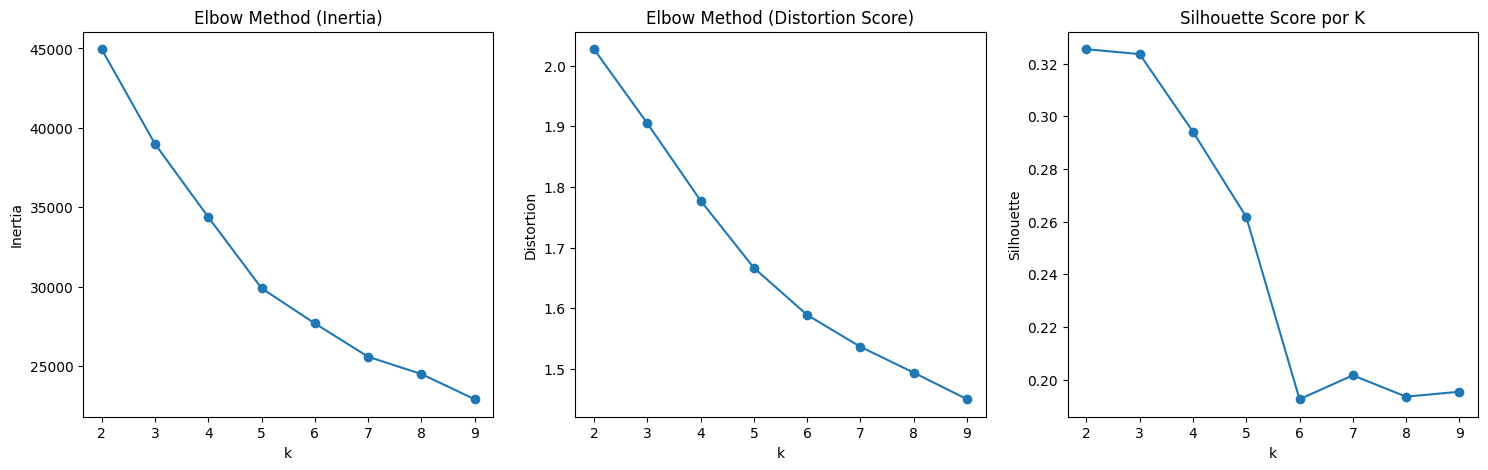

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist



inertias = []
silhouettes = []
distortions = []        # distancia promedio a los centroides
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, n_init="auto").fit(X_scaled_weather)

    # Inertia
    inertias.append(km.inertia_)

    # Silhouette
    silhouettes.append(silhouette_score(X_scaled_weather, km.labels_))

    # Distortion (
    distortion = np.mean(
        np.min(
            cdist(X_scaled_weather, km.cluster_centers_, 'euclidean'),
            axis=1
        )
    )
    distortions.append(distortion)

# Graficar
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(K, inertias, marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("k")
plt.ylabel("Inertia")

plt.subplot(1,3,2)
plt.plot(K, distortions, marker='o')
plt.title("Elbow Method (Distortion Score)")
plt.xlabel("k")
plt.ylabel("Distortion")

plt.subplot(1,3,3)
plt.plot(K, silhouettes, marker='o')
plt.title("Silhouette Score por K")
plt.xlabel("k")
plt.ylabel("Silhouette")

plt.show()


In [10]:
kmeans = KMeans(n_clusters=7, n_init='auto')
df_weather["cluster_kmeans"] = kmeans.fit_predict(X_scaled_weather)

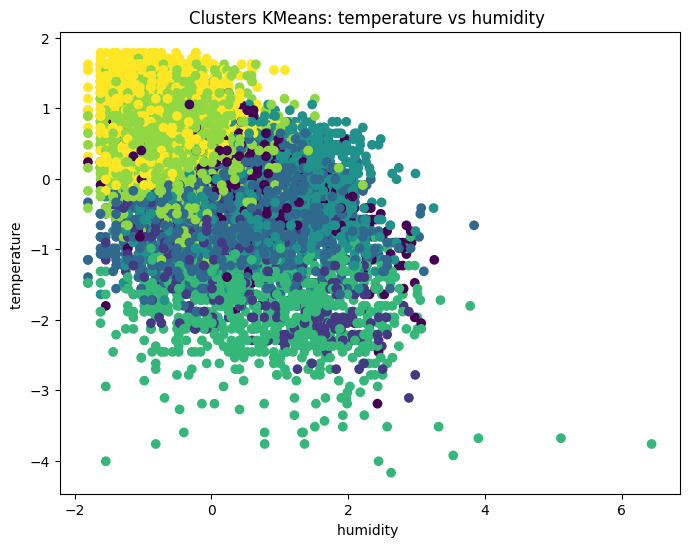

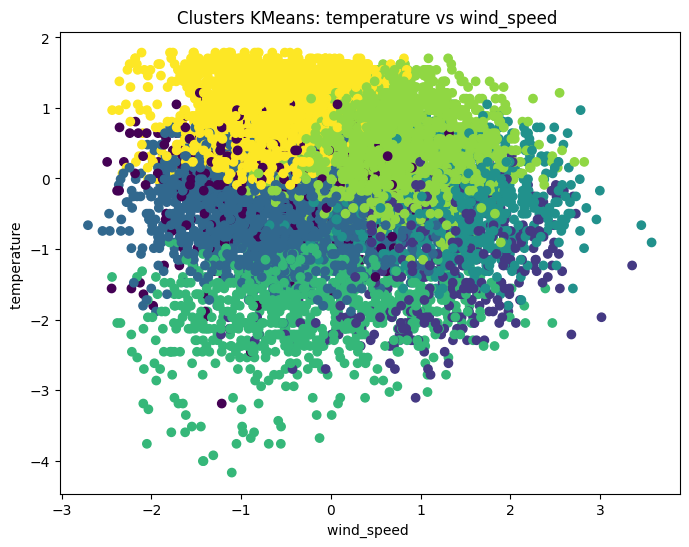

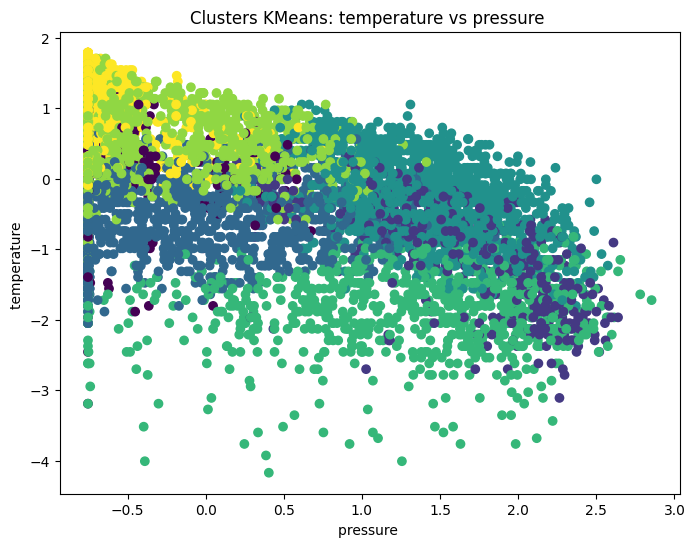

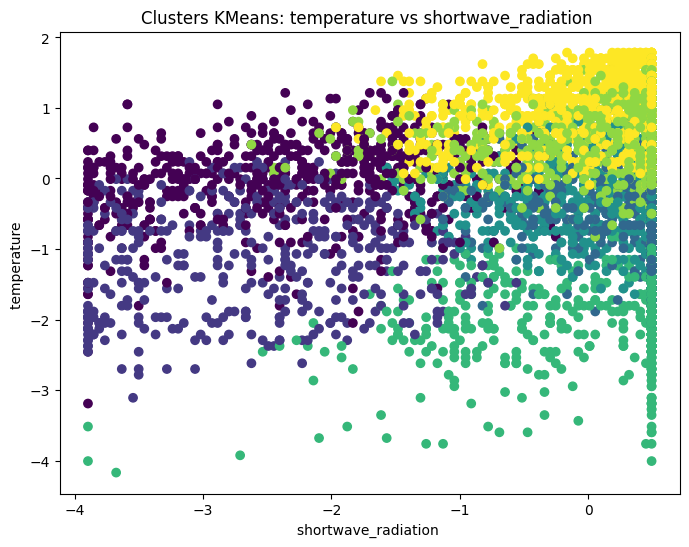

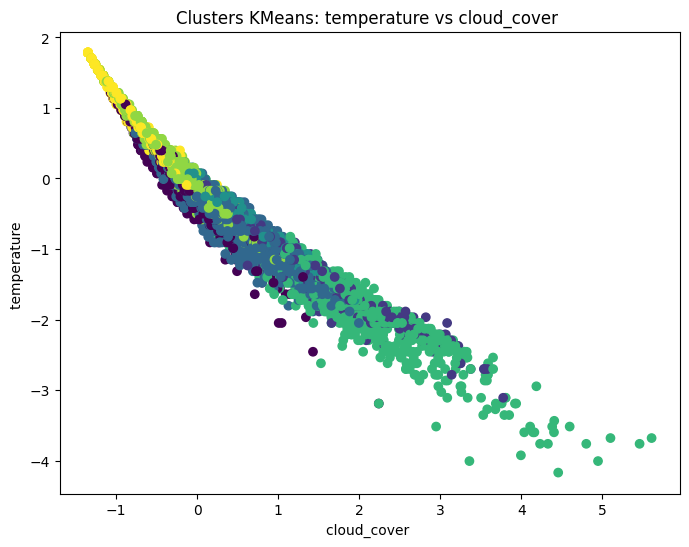

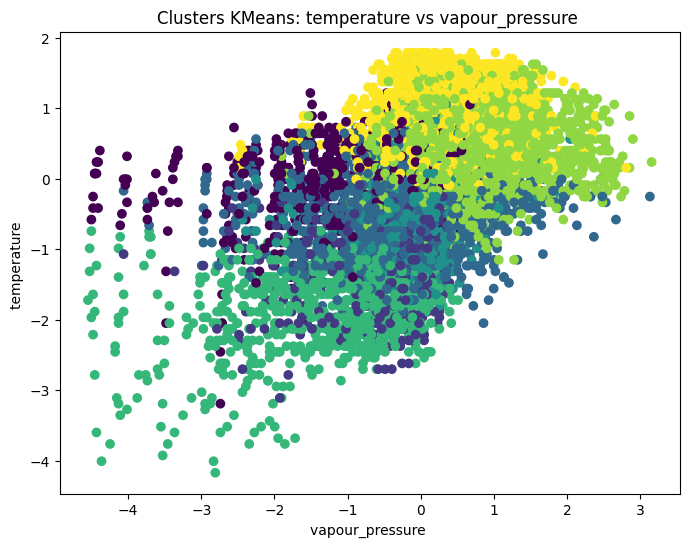

IndexError: index 7 is out of bounds for axis 1 with size 7

<Figure size 800x600 with 0 Axes>

In [12]:
# indices de cada variable en X_scaled
indices = {var: i for i, var in enumerate(df_weather)}

# índice de la temperatura dentro del X_scaled
idx_temp = indices["temperature"]

# graficar cada variable contra temperatura, ambos escalados
for var in features_weather:
    idx_var = indices[var]

    plt.figure(figsize=(8,6))
    plt.scatter(
        X_scaled_weather[:, idx_var],
        X_scaled_weather[:, idx_temp],
        c=df_weather["cluster_kmeans"]
    )
    plt.xlabel(f"{var} ")
    plt.ylabel("temperature ")
    plt.title(f"Clusters KMeans: temperature vs {var} ")
    plt.show()


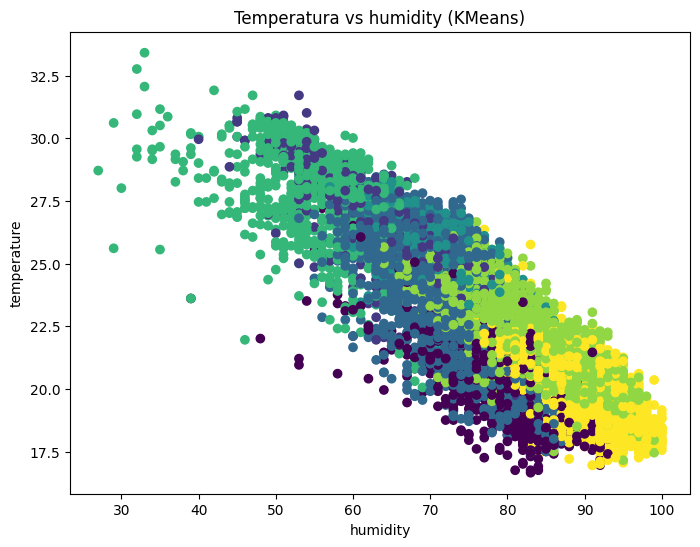

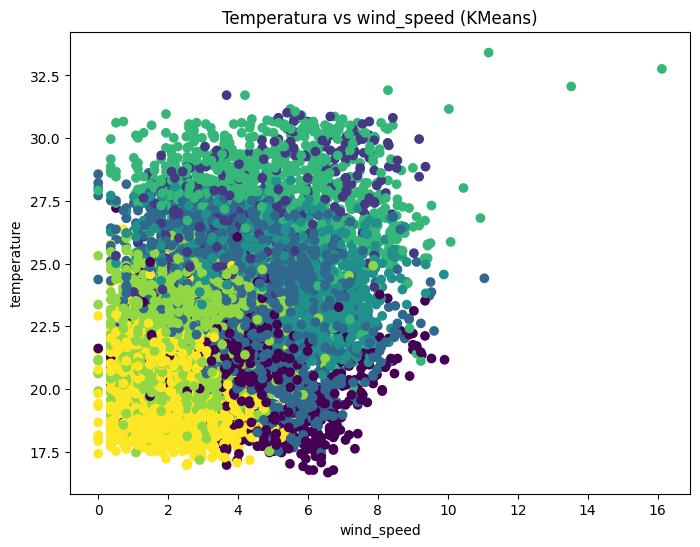

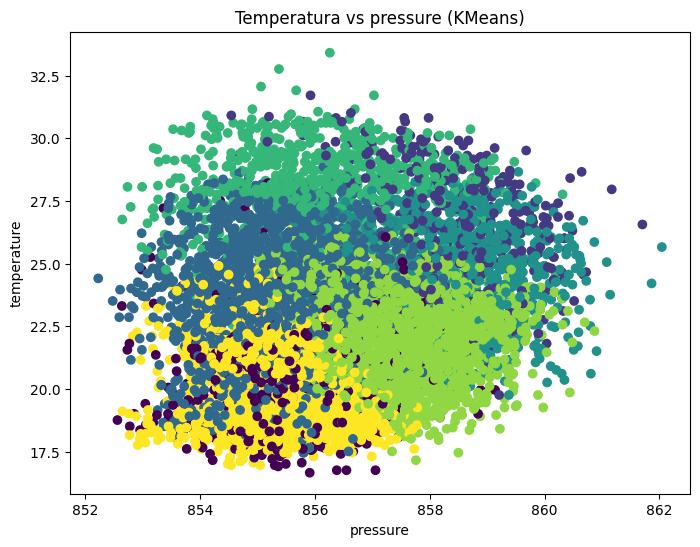

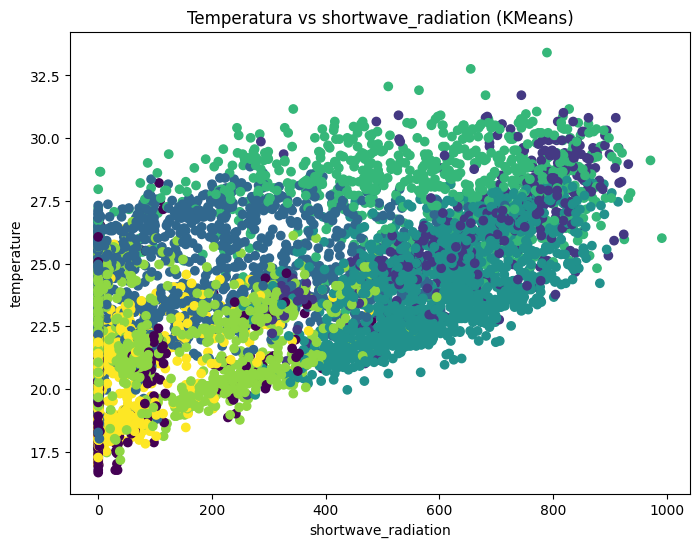

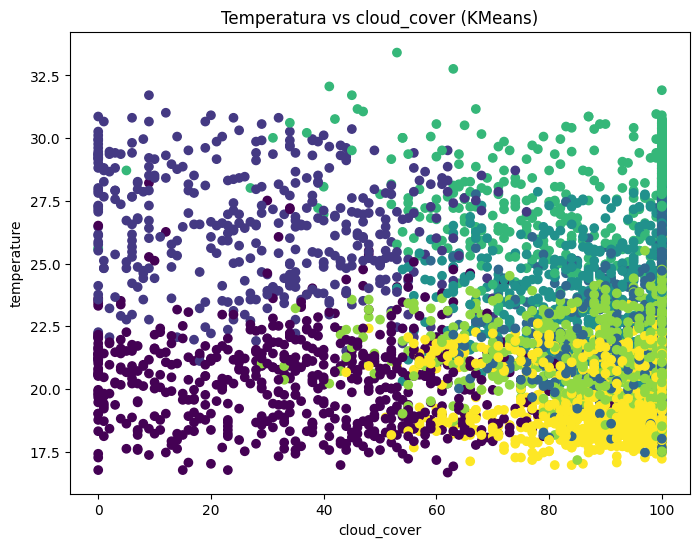

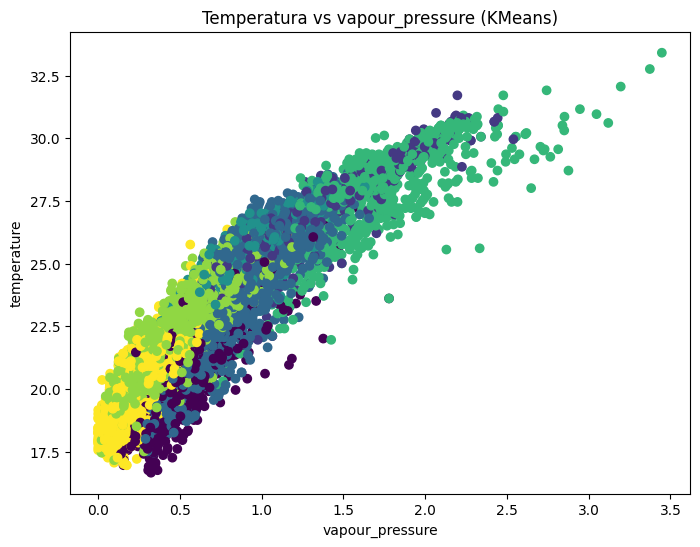

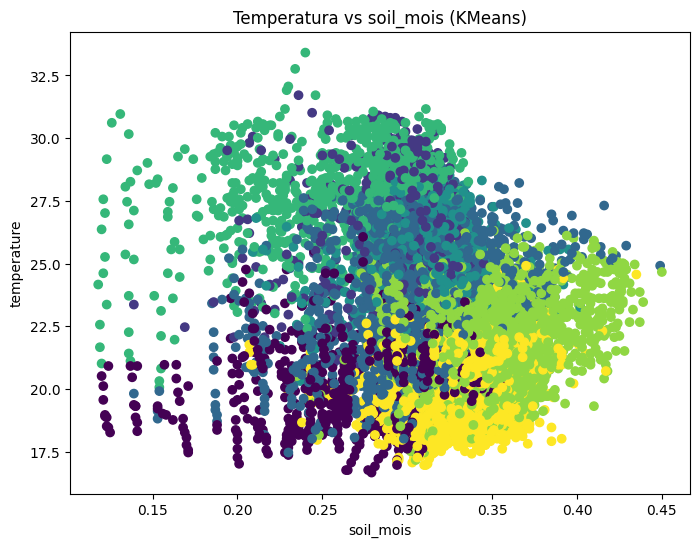

In [13]:
#SIN ESCALAR
for var in features_weather:
    plt.figure(figsize=(8,6))
    plt.scatter(df_weather[var], df_weather["temperature"],
                c=df_weather["cluster_kmeans"])
    plt.xlabel(var)
    plt.ylabel("temperature")
    plt.title(f"Temperatura vs {var} (KMeans)")
    plt.show()


In [14]:
eval_kmeans = (
    df_weather.groupby("cluster_kmeans")["temperature"]
    .agg(["mean", "std", "count"])
    .sort_index()
)

print("Evaluación por cluster (KMeans):")
print(eval_kmeans)


Evaluación por cluster (KMeans):
                     mean       std  count
cluster_kmeans                            
0               20.323427  1.846097    636
1               26.389669  2.327109    403
2               23.525551  2.397165   1831
3               24.099682  1.876515   1299
4               27.732704  1.876236    876
5               21.762968  1.651920   1924
6               19.802151  1.461897   2343


**1. Silhouette Score**

In [15]:
from sklearn.metrics import silhouette_score

# Evitamos DBSCAN donde todos sean -1 o un solo cluster
def safe_silhouette(X, labels):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        return None
    return silhouette_score(X, labels)

sil_kmeans = safe_silhouette(X_scaled_weather, df_weather["cluster_kmeans"])
print("Silhouette KMeans:", sil_kmeans)


Silhouette KMeans: 0.20166965


# DBScan - “k-distance plot”,  “Nearest
# **Neighbor Distance plot”**

**Elección de eps usando k-distance plot**

**2.1. k-distance plot**

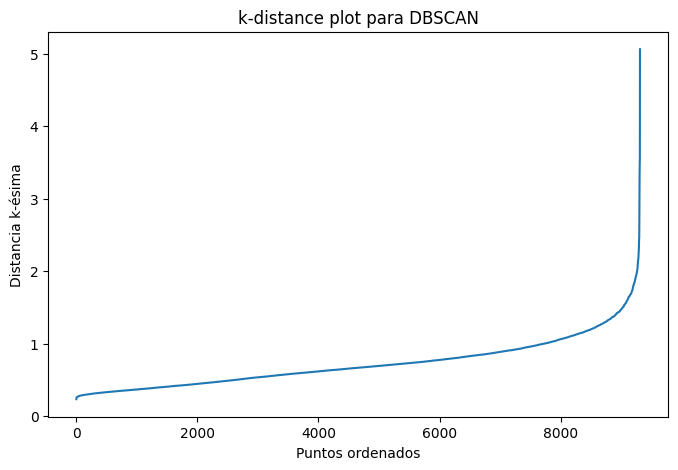

In [16]:
from sklearn.neighbors import NearestNeighbors
min_samples = len(features_weather) * 2  # 7*2=14

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled_weather)
distances, indices = neighbors_fit.kneighbors(X_scaled_weather)

k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(8,5))
plt.plot(k_dist)
plt.title("k-distance plot para DBSCAN")
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia k-ésima")
plt.show()


**2.2 Entrenar DBSCAN**

In [17]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=1.5, min_samples=min_samples)
df_weather["cluster_db"] = db.fit_predict(X_scaled_weather)


**2.3 Visualización 2D**

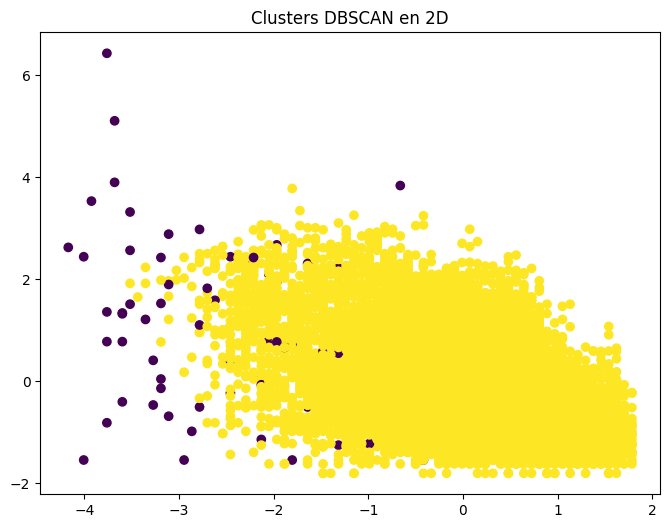

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled_weather[:,0], X_scaled_weather[:,1], c=df_weather["cluster_db"])
plt.title("Clusters DBSCAN en 2D")
plt.show()


In [19]:
eval_dbscan = (
    df_weather.groupby("cluster_db")["temperature"]
    .agg(["mean", "std", "count"])
    .sort_index()
)

print("Evaluación por cluster (DBSCAN):")
print(eval_dbscan)


Evaluación por cluster (DBSCAN):
                 mean       std  count
cluster_db                            
-1          26.811815  3.254905     73
 0          22.572409  3.069462   9239


**1. Silhouette Score**

In [20]:
sil_dbscan = safe_silhouette(X_scaled_weather, df_weather["cluster_db"])
print("Silhouette DBSCAN:", sil_dbscan)

Silhouette DBSCAN: 0.44056603


# **3. AGGLOMERATIVE CLUSTERING**

**3.1 Dendrograma para elegir número de clusters**

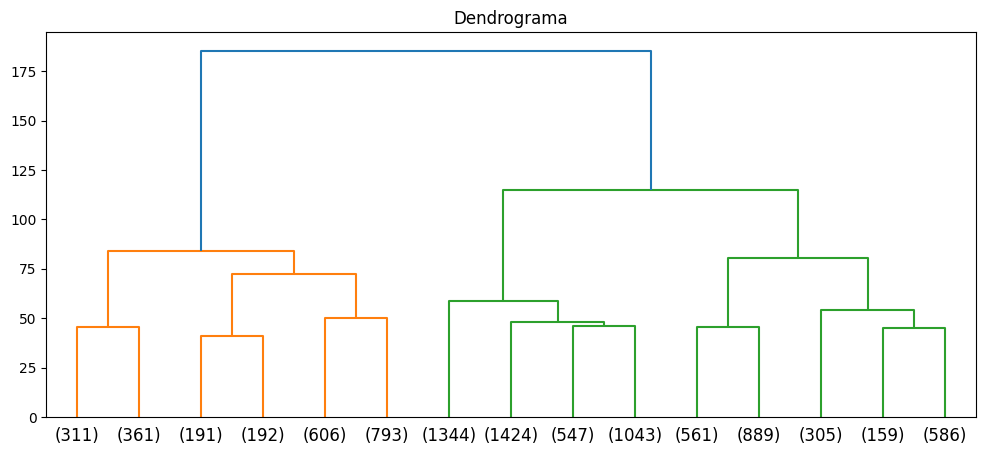

In [21]:
from scipy.cluster.hierarchy import dendrogram, linkage


Z = linkage(X_scaled_weather, method="ward")

plt.figure(figsize=(12,5))
dendrogram(Z, truncate_mode="lastp", p=15)
plt.title("Dendrograma")
plt.show()



**3.2 Entrenar Agglomerative**

In [22]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3, linkage="ward")
df_weather["cluster_agg"] = agg.fit_predict(X_scaled_weather)

**3.3 Visualización 2D**

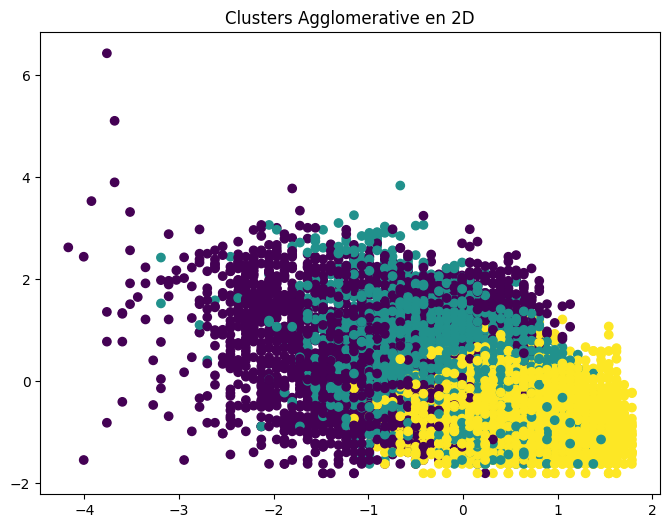

In [23]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled_weather[:,0], X_scaled_weather[:,1], c=df_weather["cluster_agg"])
plt.title("Clusters Agglomerative en 2D")
plt.show()



In [24]:
eval_aggl = (
    df_weather.groupby("cluster_agg")["temperature"]
    .agg(["mean", "std", "count"])
    .sort_index()
)

print("Evaluación por cluster (Agglomerative):")
print(eval_aggl)


Evaluación por cluster (Agglomerative):
                  mean       std  count
cluster_agg                            
0            25.884546  2.572114   2454
1            22.372200  2.604462   2500
2            20.893202  1.953215   4358


**1. Silhouette Score**

In [25]:
sil_aggl = safe_silhouette(X_scaled_weather, df_weather["cluster_agg"])
print("Silhouette Agglomerative:", sil_aggl)

Silhouette Agglomerative: 0.20820852


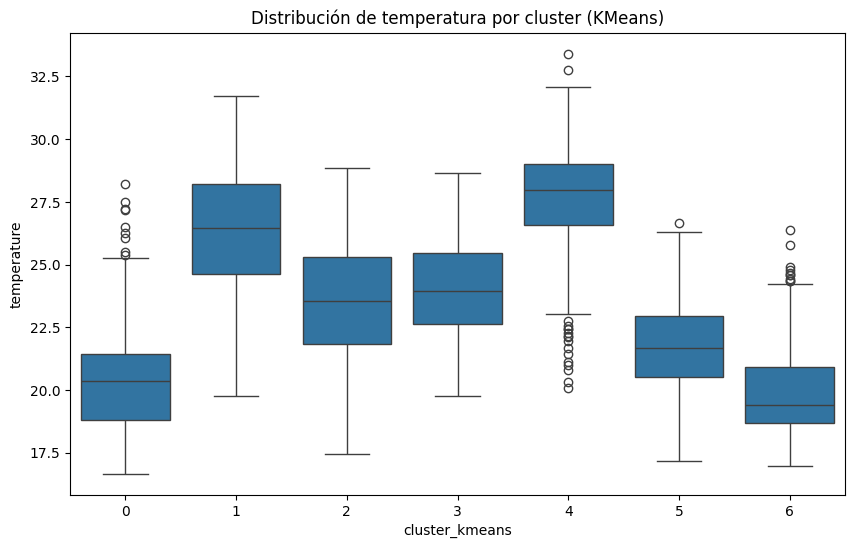

In [26]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_weather, x="cluster_kmeans", y="temperature")
plt.title("Distribución de temperatura por cluster (KMeans)")
plt.show()


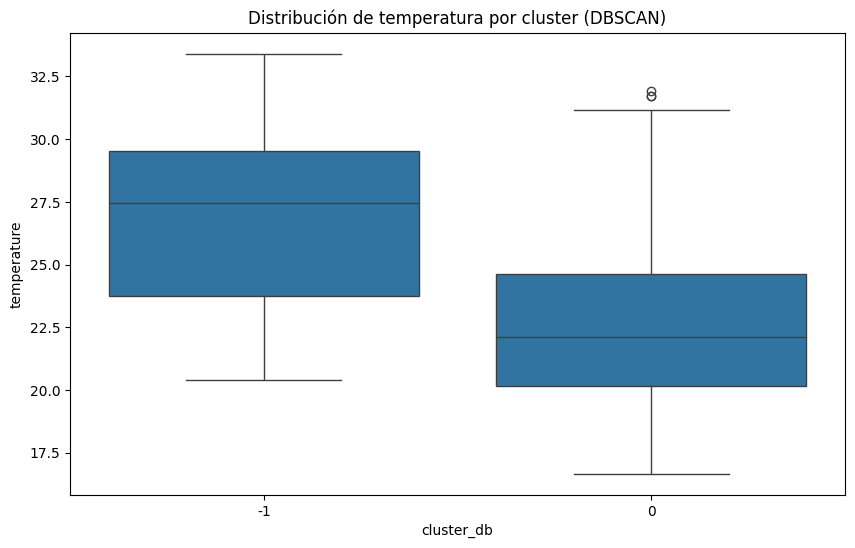

In [27]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_weather, x="cluster_db", y="temperature")
plt.title("Distribución de temperatura por cluster (DBSCAN)")
plt.show()


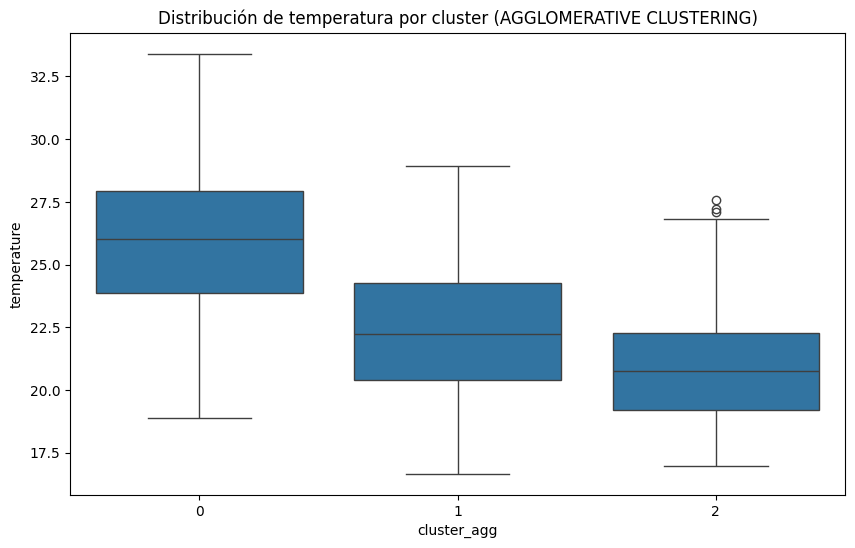

In [28]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_weather, x="cluster_agg", y="temperature")
plt.title("Distribución de temperatura por cluster (AGGLOMERATIVE CLUSTERING)")
plt.show()


**Evaluar la utilidad de los clusters dentro de un modelo supervisado, usando el
cluster ID como característica adicional y comparando su efecto en el
rendimiento (válido para clasificación y regresión).**

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

resultados = []

def evaluar_modelo(nombre, cluster_col):
    # X con variables climáticas + cluster como feature
    X = df_weather[features_weather + [cluster_col]]
    y = df_weather["temperature"]

    # split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Modelo 1: Regresión lineal
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    pred_lr = lr.predict(X_test)
    r2_lr = r2_score(y_test, pred_lr)

    # Modelo 2: Random Forest
    rf = RandomForestRegressor(n_estimators=300, random_state=42)
    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)
    r2_rf = r2_score(y_test, pred_rf)

    resultados.append([nombre, r2_lr, r2_rf])

evaluar_modelo("KMeans", "cluster_kmeans")
evaluar_modelo("DBSCAN", "cluster_db")
evaluar_modelo("Agglomerative", "cluster_agg")


df_resultados = pd.DataFrame(resultados, columns=["Algoritmo", "R2 Lineal", "R2 RandomForest"])
print(df_resultados)


       Algoritmo  R2 Lineal  R2 RandomForest
0         KMeans   0.927901         0.991127
1         DBSCAN   0.923211         0.990653
2  Agglomerative   0.923481         0.990626


In [30]:
y = df_weather["temperature"].values
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_weather, y, test_size=0.2, random_state=42
)

# Baseline modelos sin cluster
lr_base = LinearRegression().fit(X_train, y_train)
rf_base = RandomForestRegressor(random_state=42).fit(X_train, y_train)

r2_lr_base = r2_score(y_test, lr_base.predict(X_test))
r2_rf_base = r2_score(y_test, rf_base.predict(X_test))

print("Baseline LR R2:", r2_lr_base)
print("Baseline RF R2:", r2_rf_base)


Baseline LR R2: 0.9219346642494202
Baseline RF R2: 0.9902576599126439


In [31]:
def evaluar_cluster(df, col_cluster):
    Xc = np.column_stack([X_scaled_weather, df[col_cluster].values])
    Xc_train, Xc_test, yc_train, yc_test = train_test_split(
        Xc, y, test_size=0.2, random_state=42
    )

    lr = LinearRegression().fit(Xc_train, yc_train)
    rf = RandomForestRegressor(random_state=42).fit(Xc_train, yc_train)

    return r2_score(yc_test, lr.predict(Xc_test)), r2_score(yc_test, rf.predict(Xc_test))


In [32]:
r2_lr_kmeans, r2_rf_kmeans = evaluar_cluster(df_weather, "cluster_kmeans")
r2_lr_dbscan, r2_rf_dbscan = evaluar_cluster(df_weather, "cluster_db")
r2_lr_agg, r2_rf_agg = evaluar_cluster(df_weather, "cluster_agg")

print("KMeans  -> LR:", r2_lr_kmeans, " RF:", r2_rf_kmeans)
print("DBSCAN  -> LR:", r2_lr_dbscan, " RF:", r2_rf_dbscan)
print("Agg     -> LR:", r2_lr_agg,    " RF:", r2_rf_agg)


KMeans  -> LR: 0.9279011539239621  RF: 0.9906961949098358
DBSCAN  -> LR: 0.9232106993368451  RF: 0.9904100934813838
Agg     -> LR: 0.9234806482053146  RF: 0.990318714939712


In [33]:
tabla = pd.DataFrame({
    "Algoritmo": ["Sin clusters", "KMeans", "DBSCAN", "Agglomerative"],
    "R2 Lineal": [r2_lr_base, r2_lr_kmeans, r2_lr_dbscan, r2_lr_agg],
    "R2 RandomForest": [r2_rf_base, r2_rf_kmeans, r2_rf_dbscan, r2_rf_agg]
})

display(tabla)


,Algoritmo,R2 Lineal,R2 RandomForest
0,Sin clusters,0.921935,0.990258
1,KMeans,0.927901,0.990696
2,DBSCAN,0.923211,0.990410
3,Agglomerative,0.923481,0.990319


# 1. KMEANS **AIR POLLUTION**
***1.1. Elbow Method + Silhouette Score***

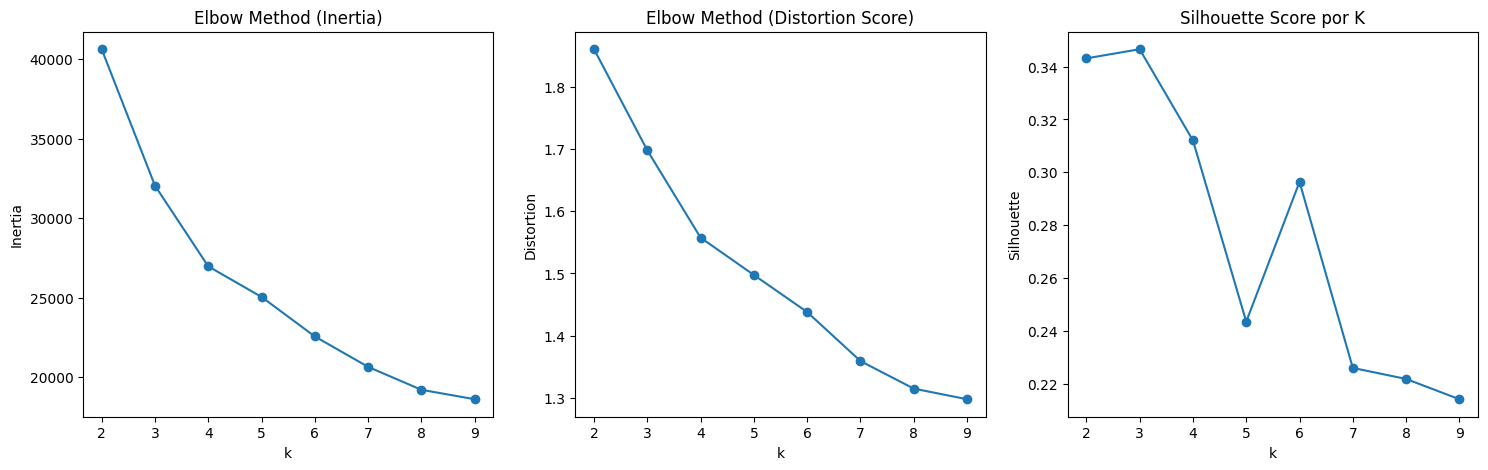

In [34]:
from scipy.spatial.distance import cdist

inertias_air = []
silhouettes_air = []
distortions_air = []    # lista correcta

K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, n_init="auto").fit(X_scaled_air)

    # Inertia
    inertias_air.append(km.inertia_)

    # Silhouette
    silhouettes_air.append(silhouette_score(X_scaled_air, km.labels_))

    # Distortion (distancia promedio al centro más cercano)
    distortion_k = np.mean(
        np.min(
            cdist(X_scaled_air, km.cluster_centers_, 'euclidean'),
            axis=1
        )
    )
    distortions_air.append(distortion_k)

# Graficar
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(K, inertias_air, marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("k")
plt.ylabel("Inertia")

plt.subplot(1,3,2)
plt.plot(K, distortions_air, marker='o')
plt.title("Elbow Method (Distortion Score)")
plt.xlabel("k")
plt.ylabel("Distortion")

plt.subplot(1,3,3)
plt.plot(K, silhouettes_air, marker='o')
plt.title("Silhouette Score por K")
plt.xlabel("k")
plt.ylabel("Silhouette")

plt.show()



**2.2 Entrenar KMEANS AIR POLLUTION**

In [35]:
kmeans = KMeans(n_clusters=7, n_init='auto', random_state=42)
df_air["cluster_kmeans"] = kmeans.fit_predict(X_scaled_air)

In [36]:
print(features_air)

['co', 'no2', 'so2', 'o3', 'aero_op', 'ch4', 'no']


# VISUALIZACION 2D

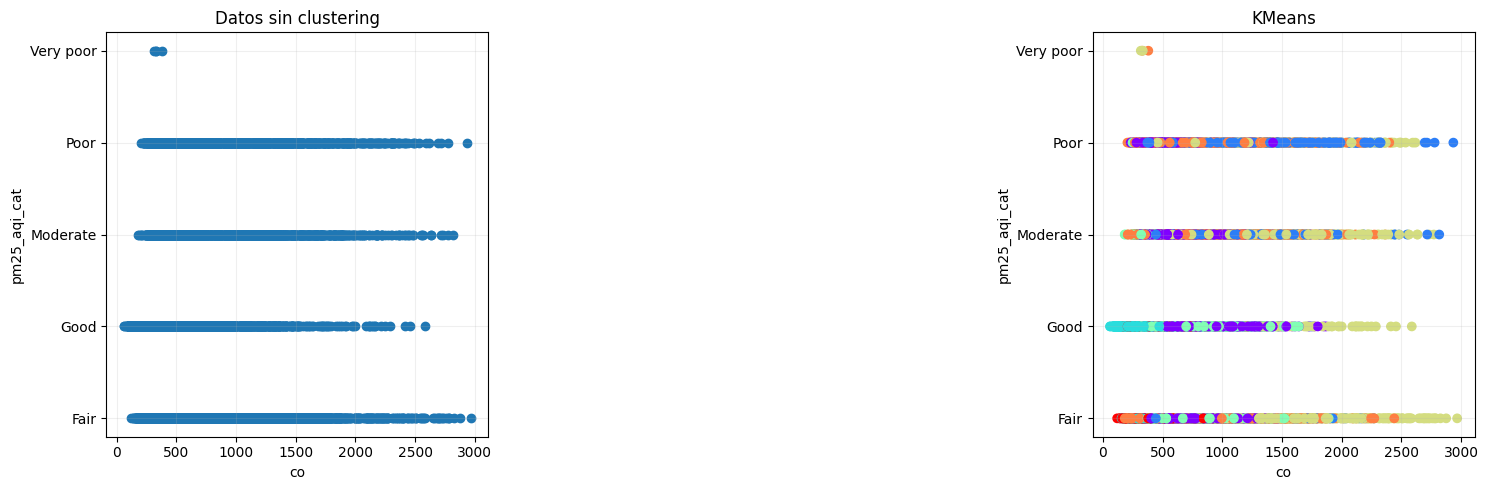

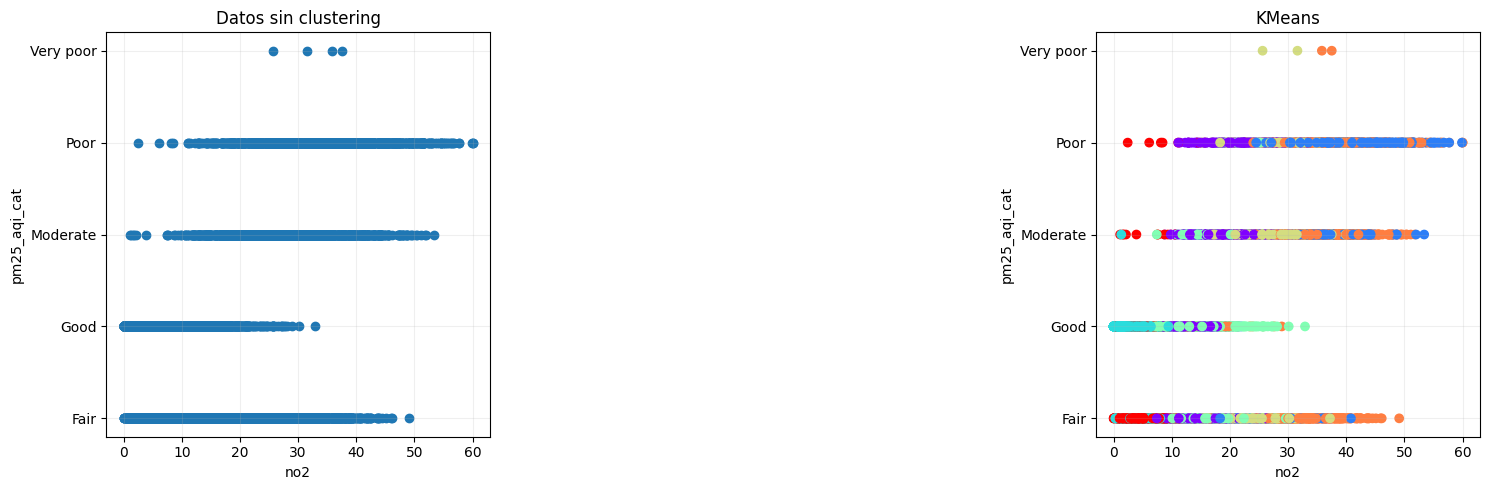

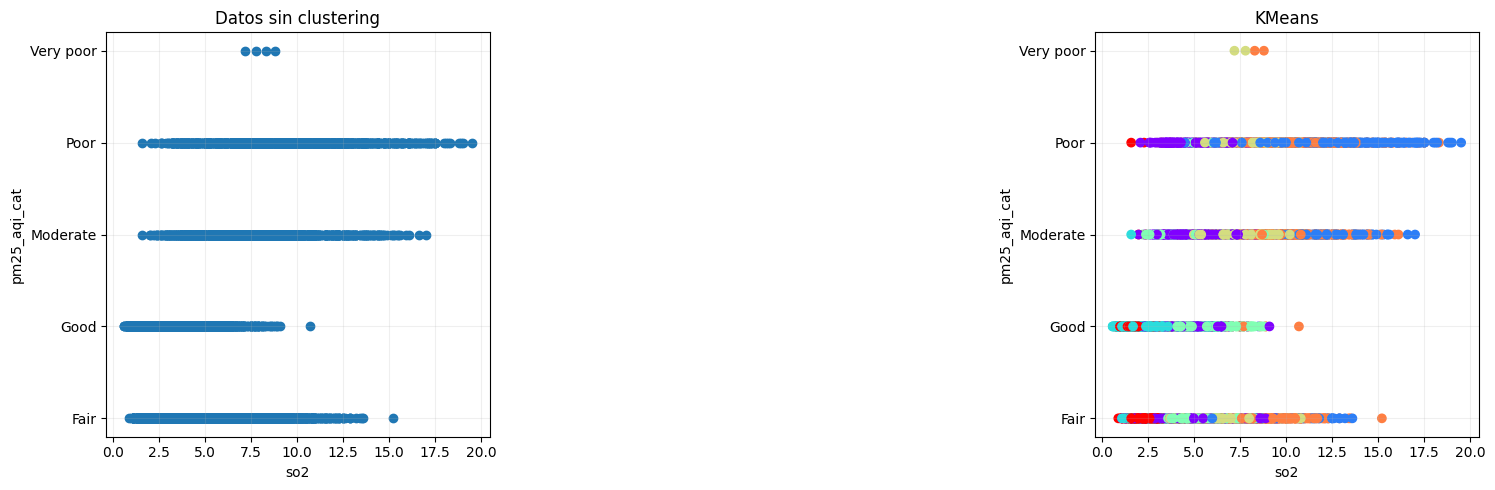

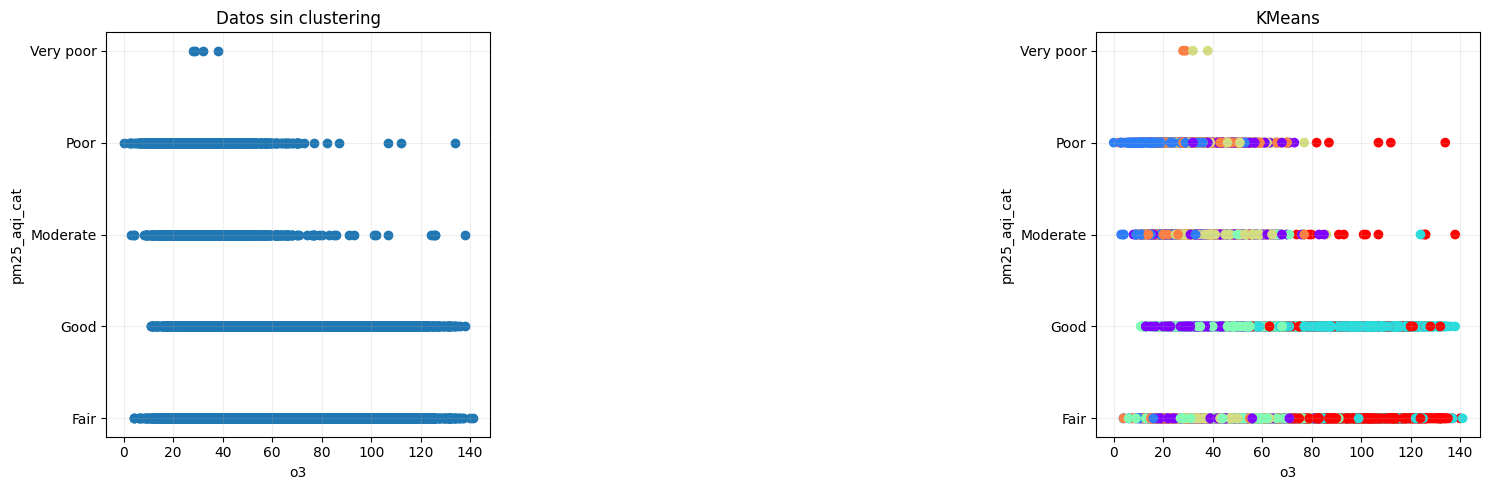

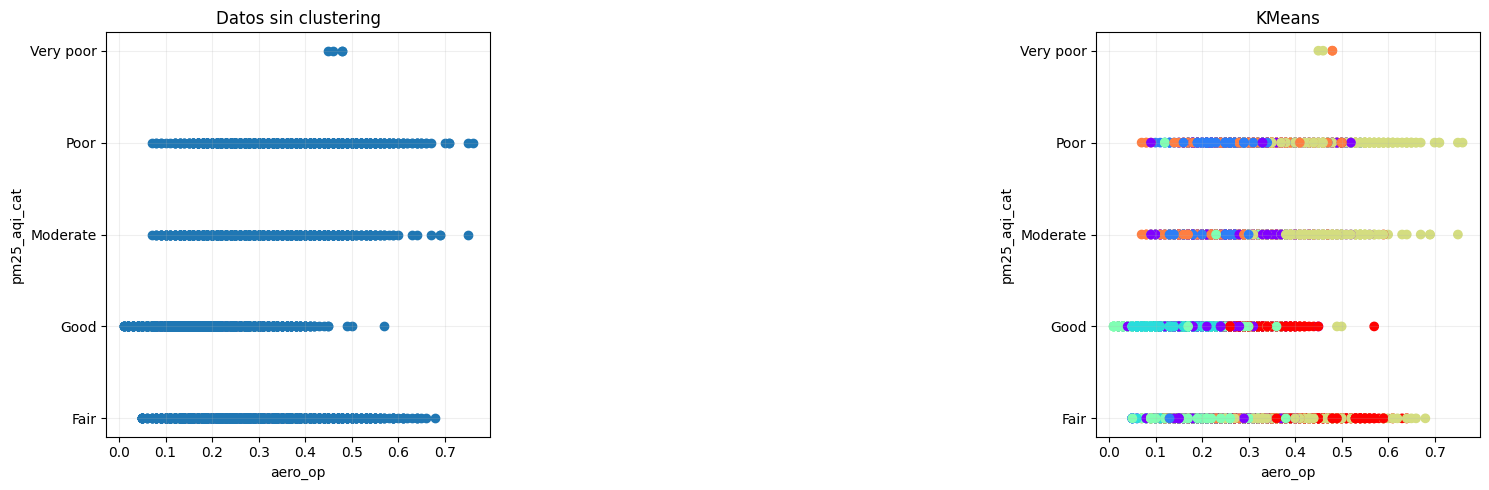

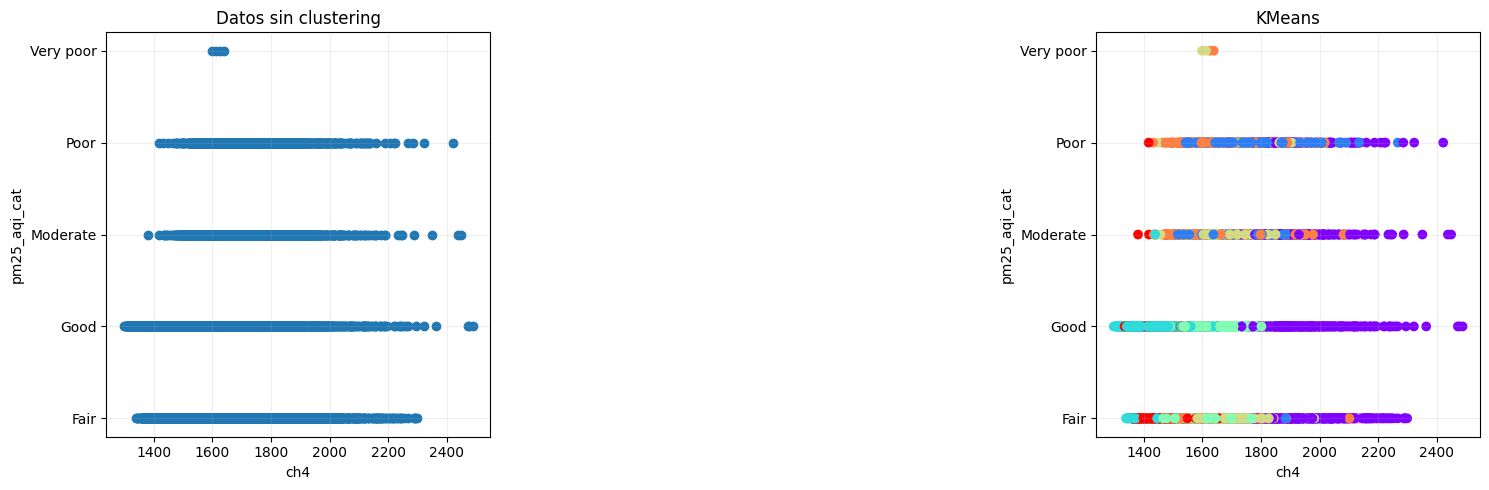

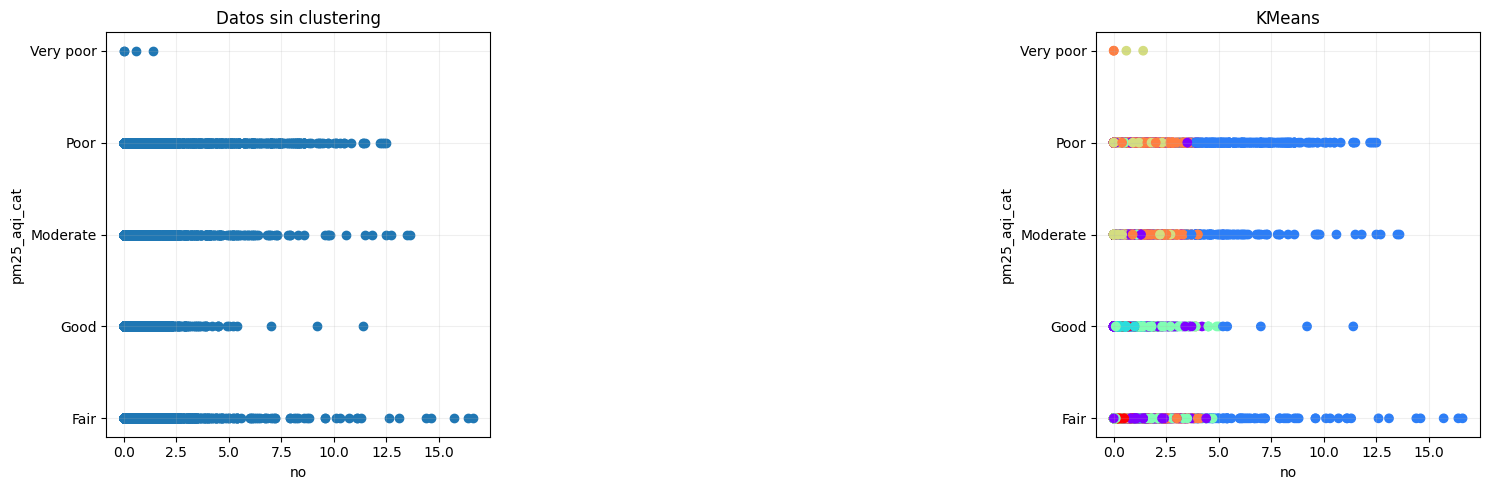

In [37]:
for var in features_air:

    plt.figure(figsize=(15,5))

    # 1) Scatter sin clusters
    plt.subplot(131)
    plt.scatter(df_air[var], df_air["pm25_aqi_cat"])
    plt.xlabel(var)
    plt.ylabel("pm25_aqi_cat")
    plt.title("Datos sin clustering")
    plt.grid(alpha=0.2)

    # 2) KMeans clustering
    plt.subplot(133)
    plt.scatter(df_air[var],
                df_air["pm25_aqi_cat"],
                c=df_air["cluster_kmeans"],
                cmap="rainbow")
    plt.xlabel(var)
    plt.ylabel("pm25_aqi_cat")
    plt.title("KMeans")
    plt.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


**1. Métricas para evaluar compactación y separación interna: Silhouette Score**

In [38]:
sil_kmeans = safe_silhouette(X_scaled_weather, df_air["cluster_kmeans"])
print("Silhouette KMeans:", sil_kmeans)


Silhouette KMeans: -0.056197975


 **2. Comparación con etiquetas verdaderas:
○ Clasificación: comparar con etiquetas verdaderas, calculando métricas
como el Accuracy o usando herramientas como la matriz de confusión.**



Accuracy KMeans: 0.08161512027491409


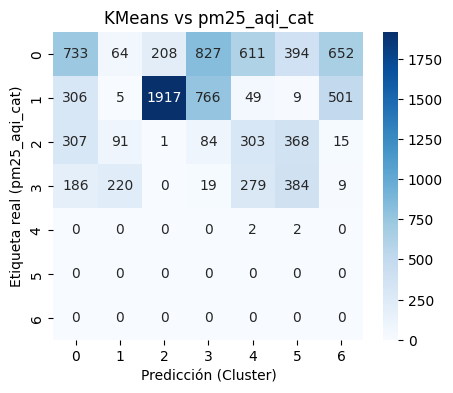

In [39]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Crear copia del dataset para la evaluación de clusters vs etiquetas verdaderas
df_eval = df_air.copy()

# Convertir la columna de categorías a números en la copia
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_eval["pm25_aqi_cat_num"] = le.fit_transform(df_eval["pm25_aqi_cat"])

y_true = df_eval["pm25_aqi_cat_num"]
y_pred = df_eval["cluster_kmeans"]

acc_kmeans = accuracy_score(y_true, y_pred)
cm_kmeans = confusion_matrix(y_true, y_pred)

print("Accuracy KMeans:", acc_kmeans)

plt.figure(figsize=(5,4))
sns.heatmap(cm_kmeans, annot=True, fmt="d", cmap="Blues")
plt.title("KMeans vs pm25_aqi_cat")
plt.xlabel("Predicción (Cluster)")
plt.ylabel("Etiqueta real (pm25_aqi_cat)")
plt.show()


# DBSCAN

* Selección de hiperparámetros con k-distance plot






**Selección de hiperparámetros con k-distance plot**

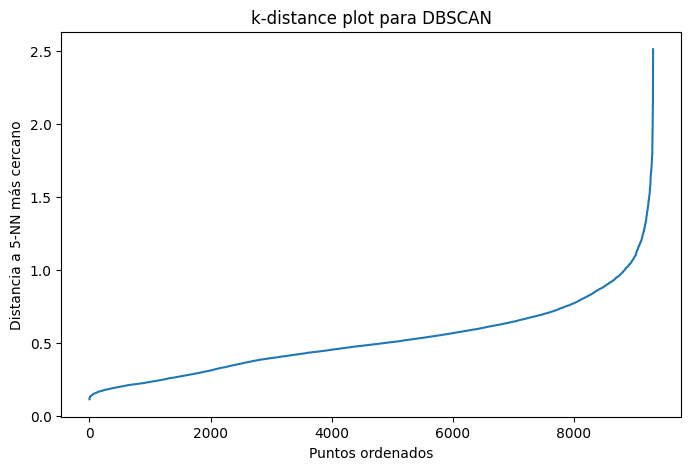

In [40]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled_air)
distances, indices = neighbors_fit.kneighbors(X_scaled_air)
distances = np.sort(distances[:,4])  # 4 = n_neighbors-1

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.ylabel("Distancia a 5-NN más cercano")
plt.xlabel("Puntos ordenados")
plt.title("k-distance plot para DBSCAN")
plt.show()


**Entrenar DBSCAN**

In [41]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=1, min_samples=5)  # eps según k-distance plot
df_air["cluster_dbscan"] = dbscan.fit_predict(X_scaled_air)


**Visualización 2D**

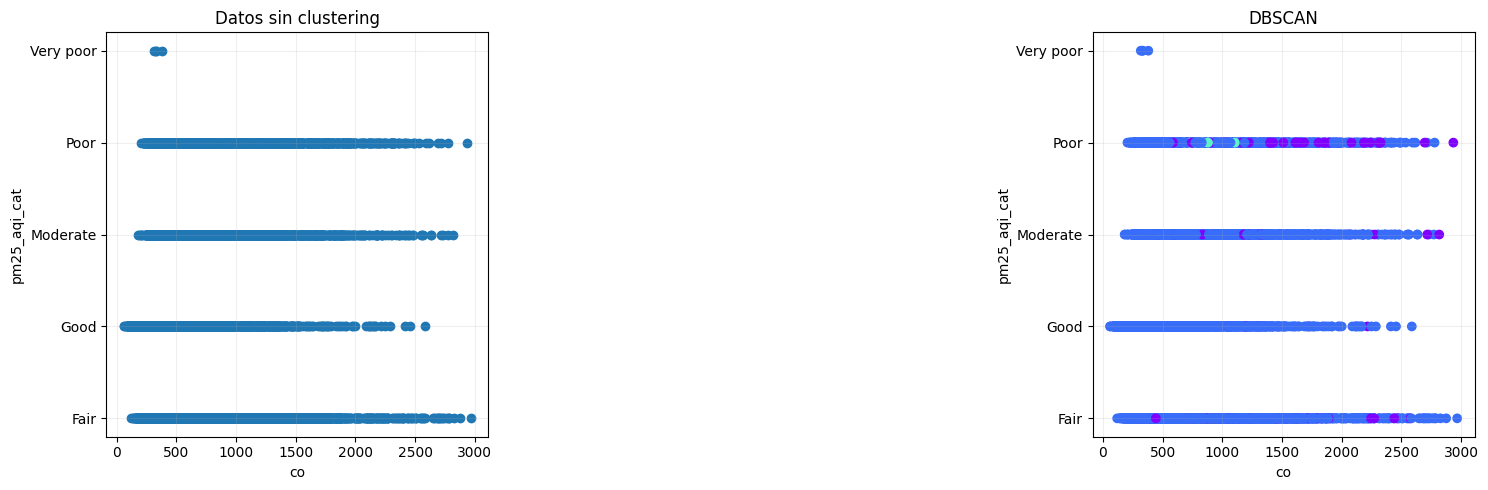

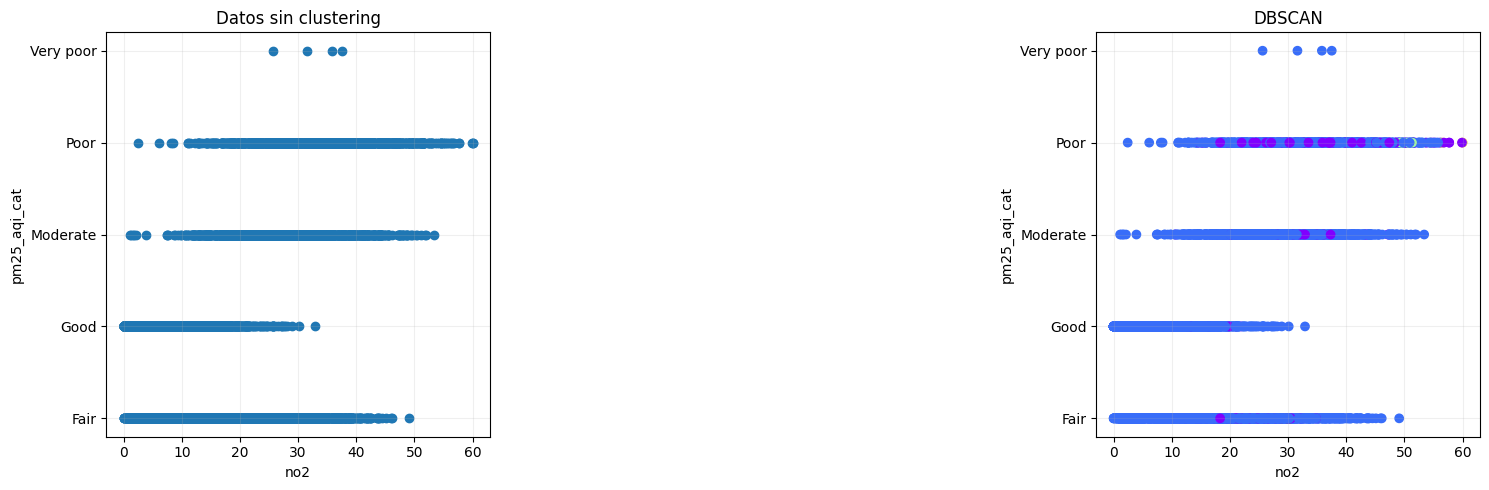

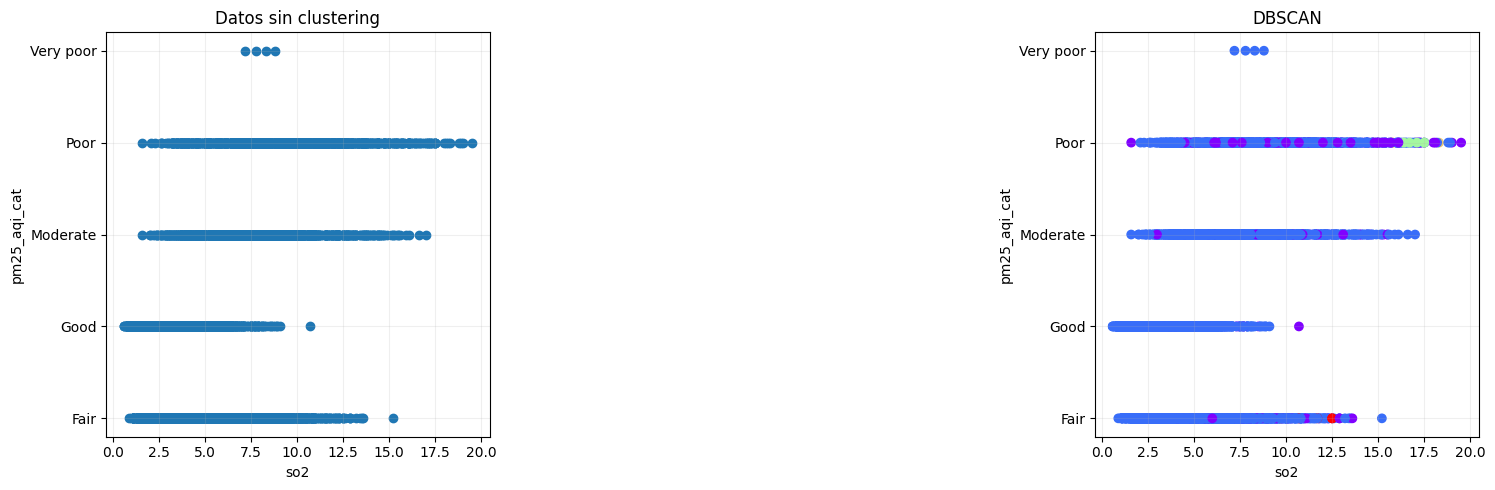

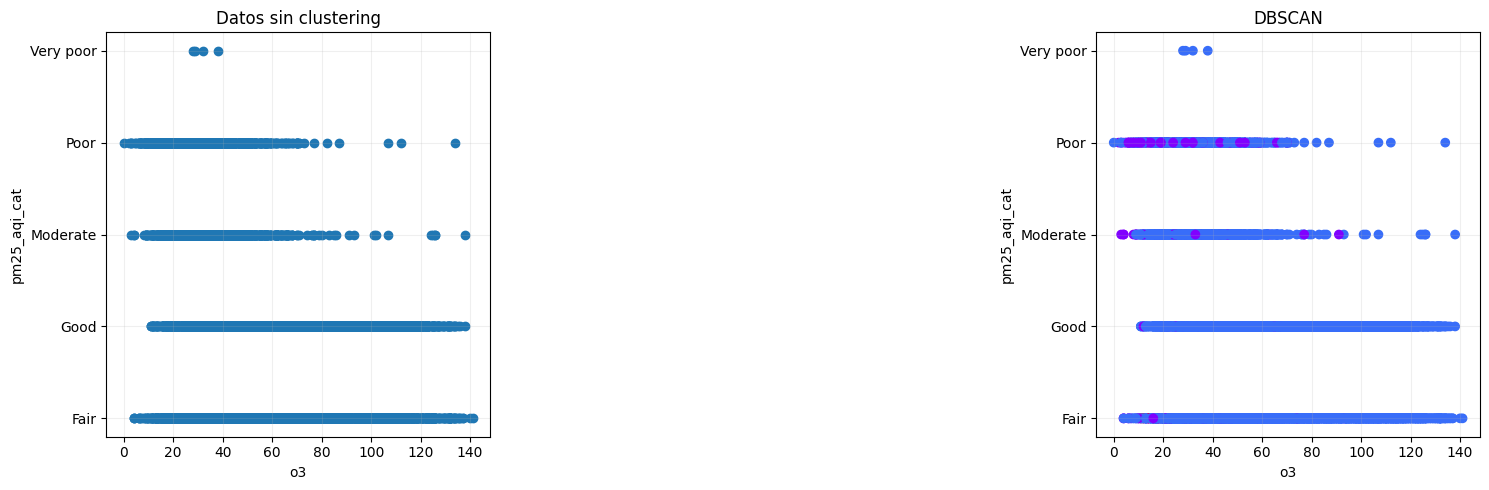

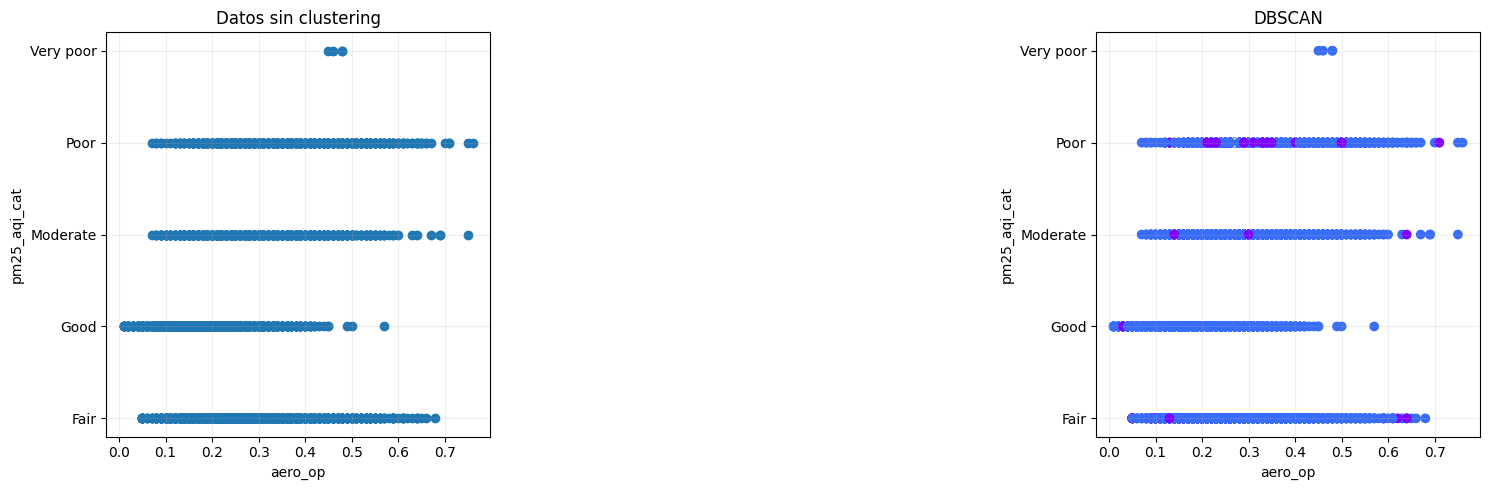

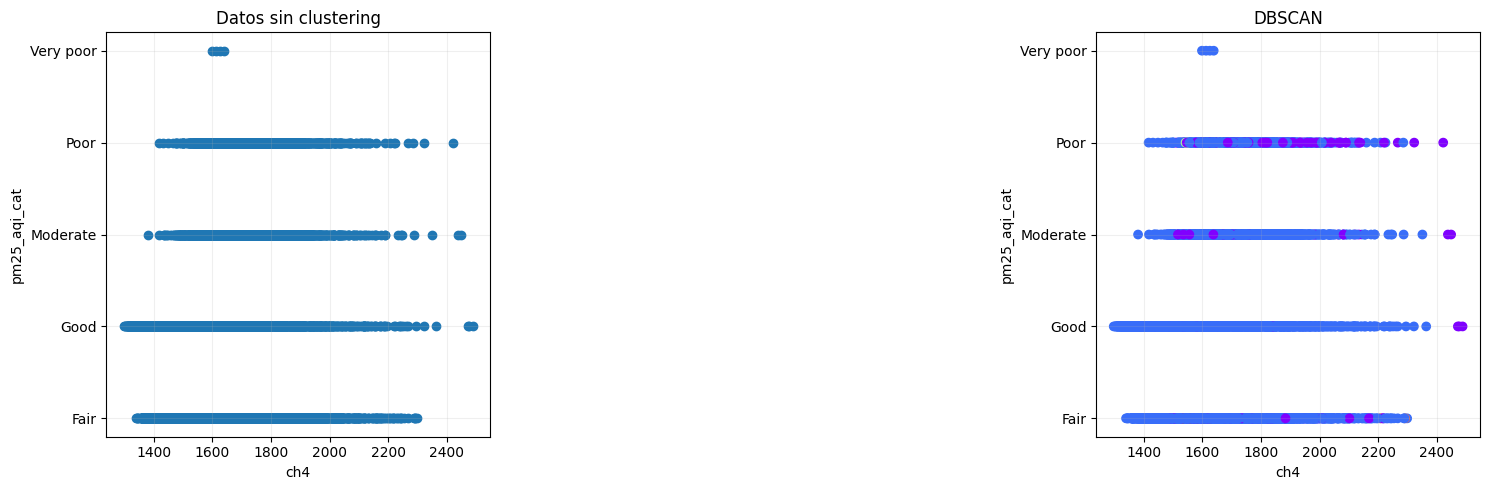

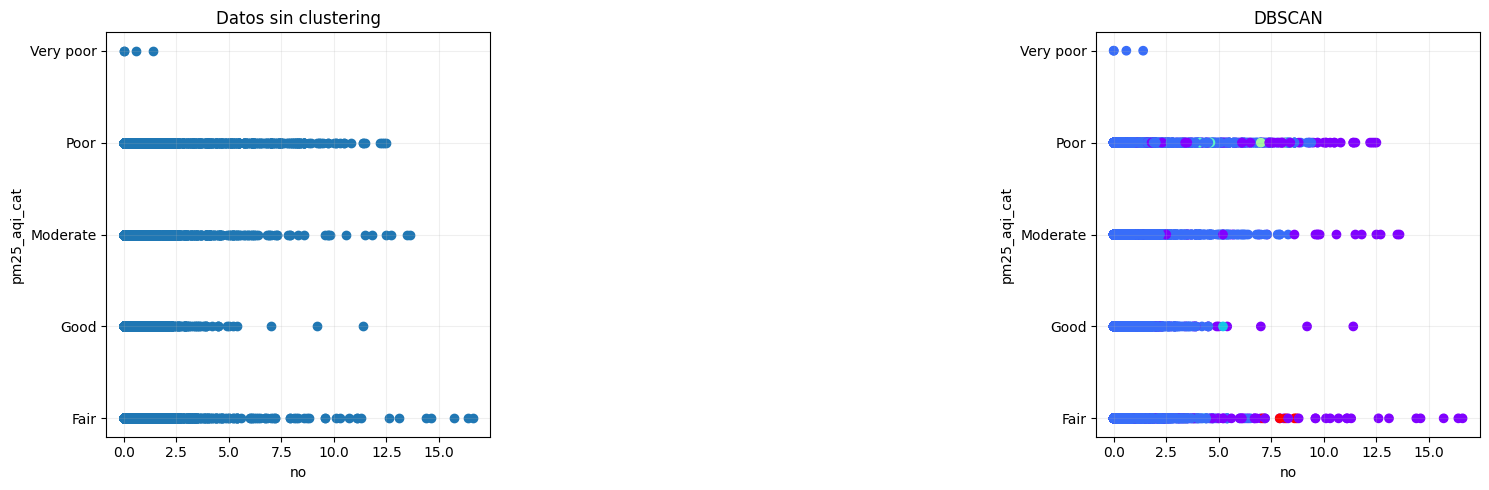

In [42]:
for var in features_air:

    plt.figure(figsize=(15,5))

    # 1) Sin clustering
    plt.subplot(131)
    plt.scatter(df_air[var], df_air["pm25_aqi_cat"])
    plt.xlabel(var)
    plt.ylabel("pm25_aqi_cat")
    plt.title("Datos sin clustering")
    plt.grid(alpha=0.2)

    # 2) DBSCAN clustering
    plt.subplot(133)
    plt.scatter(df_air[var],
                df_air["pm25_aqi_cat"],
                c=df_air["cluster_dbscan"],
                cmap="rainbow")
    plt.xlabel(var)
    plt.ylabel("pm25_aqi_cat")
    plt.title("DBSCAN")
    plt.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


**Métricas para evaluar compactación y separación interna: Silhouette Score**

In [43]:
sil_dbscan = safe_silhouette(X_scaled_weather, df_air["cluster_dbscan"])
print("Silhouette KMeans:", sil_dbscan)

Silhouette KMeans: -0.31861594


 **2. Comparación con etiquetas verdaderas:
○ Clasificación: comparar con etiquetas verdaderas, calculando métricas
como el Accuracy o usando herramientas como la matriz de confusión.**


In [44]:
from sklearn.cluster import DBSCAN

# Ajustamos eps para unir más puntos y tener menos clusters
dbscan = DBSCAN(eps=1.5, min_samples=5)  # puedes ajustar eps según tus datos
df_eval["cluster_dbscan"] = dbscan.fit_predict(X_scaled_air)

# Revisamos cuántos clusters diferentes tenemos (incluye -1 de ruido)
print("Clusters únicos DBSCAN:", np.unique(df_eval["cluster_dbscan"]))


Clusters únicos DBSCAN: [-1  0  1  2]


Accuracy DBSCAN: 0.37376237623762376
Número de puntos considerados: 9292


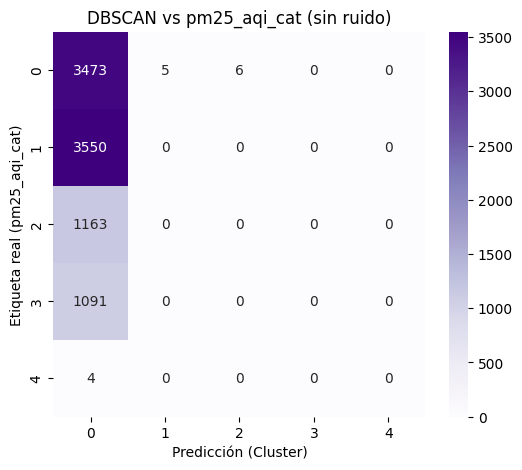

In [45]:

from sklearn.metrics import confusion_matrix, accuracy_score

# Reemplazar -1 (ruido) por NaN para no contar en la matriz
y_pred_clean = df_eval["cluster_dbscan"].replace(-1, np.nan)
y_true_clean = df_eval["pm25_aqi_cat_num"].copy()

# Solo consideramos filas que no son ruido
mask = ~y_pred_clean.isna()
y_pred_clean = y_pred_clean[mask]
y_true_clean = y_true_clean[mask]

# Accuracy y matriz de confusión
acc_dbscan = accuracy_score(y_true_clean, y_pred_clean)
cm_dbscan = confusion_matrix(y_true_clean, y_pred_clean)

print("Accuracy DBSCAN:", acc_dbscan)
print("Número de puntos considerados:", len(y_true_clean))

# Graficar matriz
plt.figure(figsize=(6,5))
sns.heatmap(cm_dbscan, annot=True, fmt="d", cmap="Purples")
plt.title("DBSCAN vs pm25_aqi_cat (sin ruido)")
plt.xlabel("Predicción (Cluster)")
plt.ylabel("Etiqueta real (pm25_aqi_cat)")
plt.show()



# **kmeans vs DBScan**

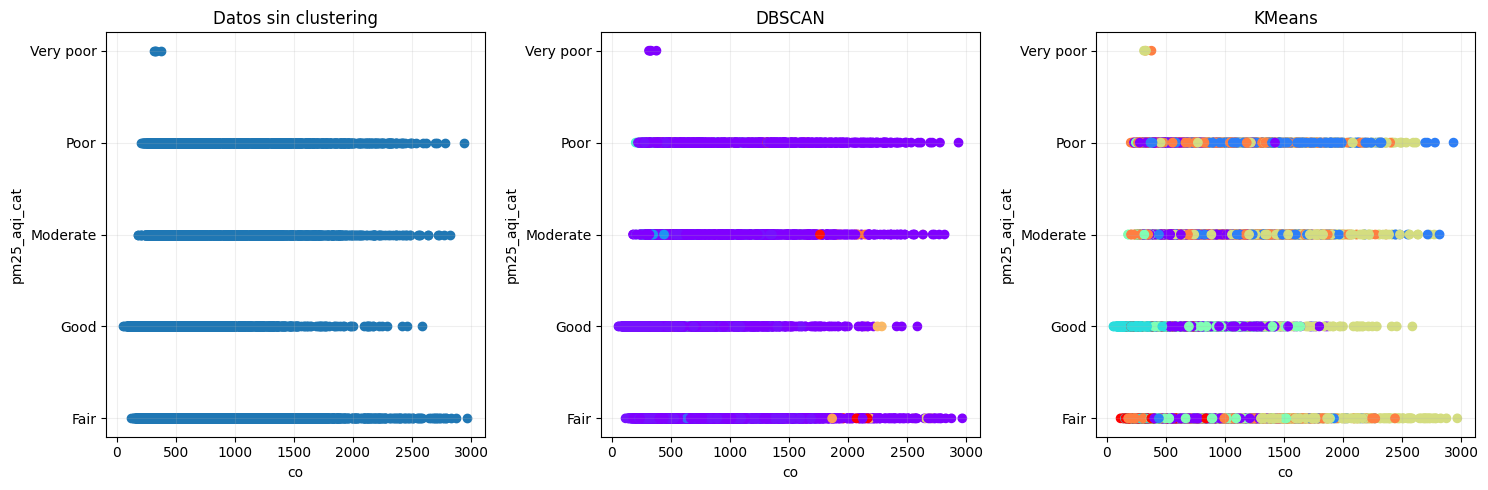

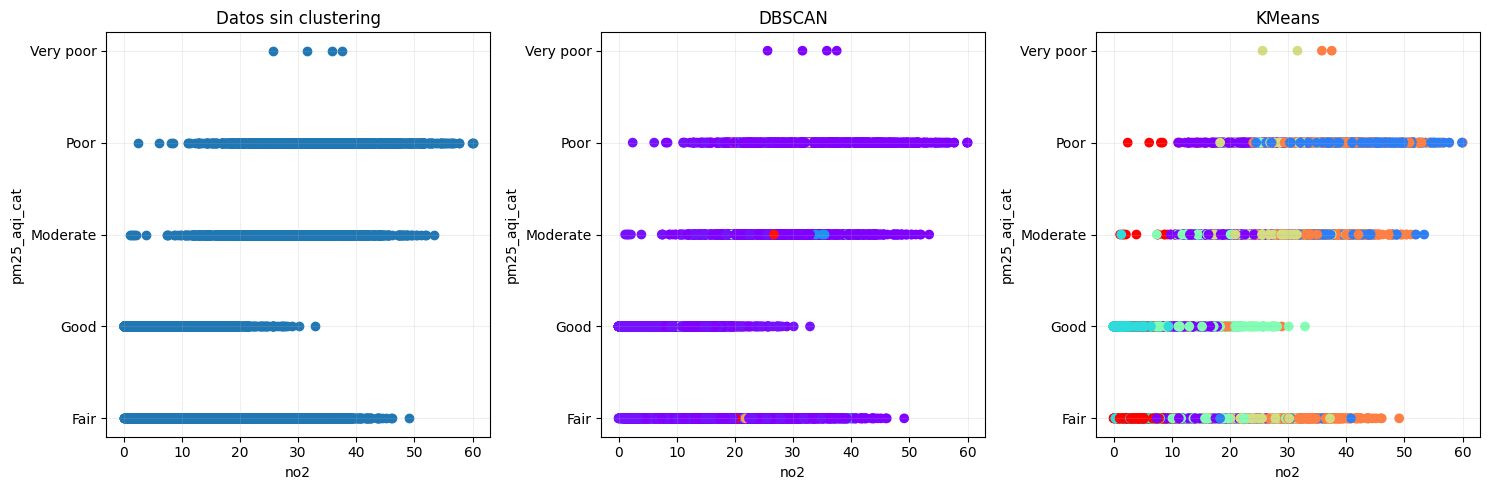

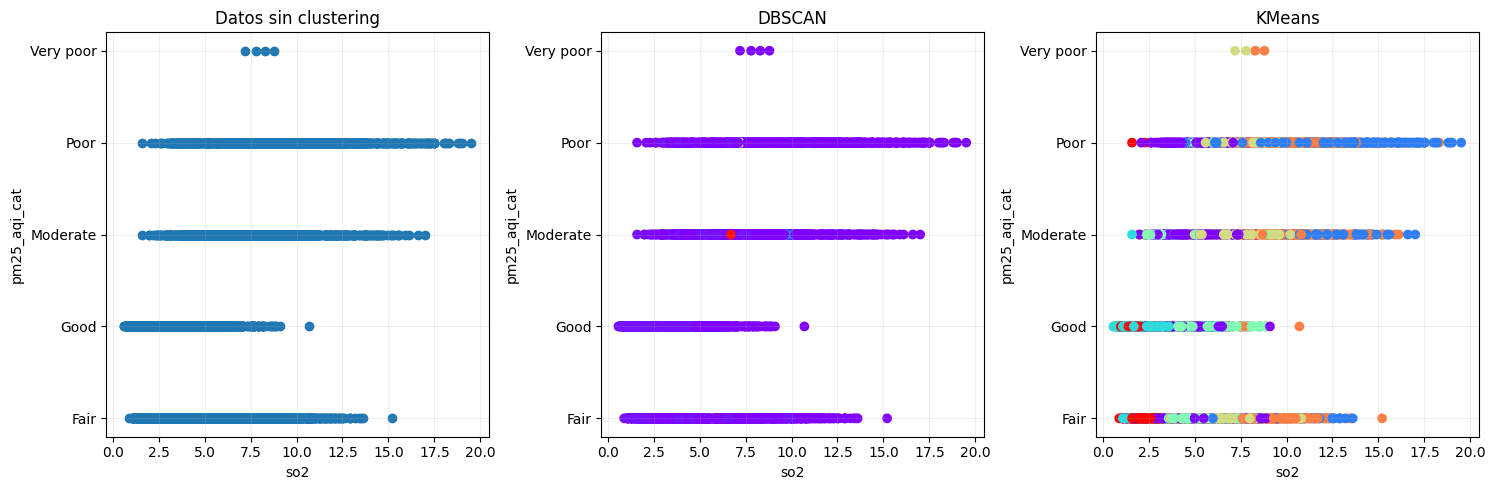

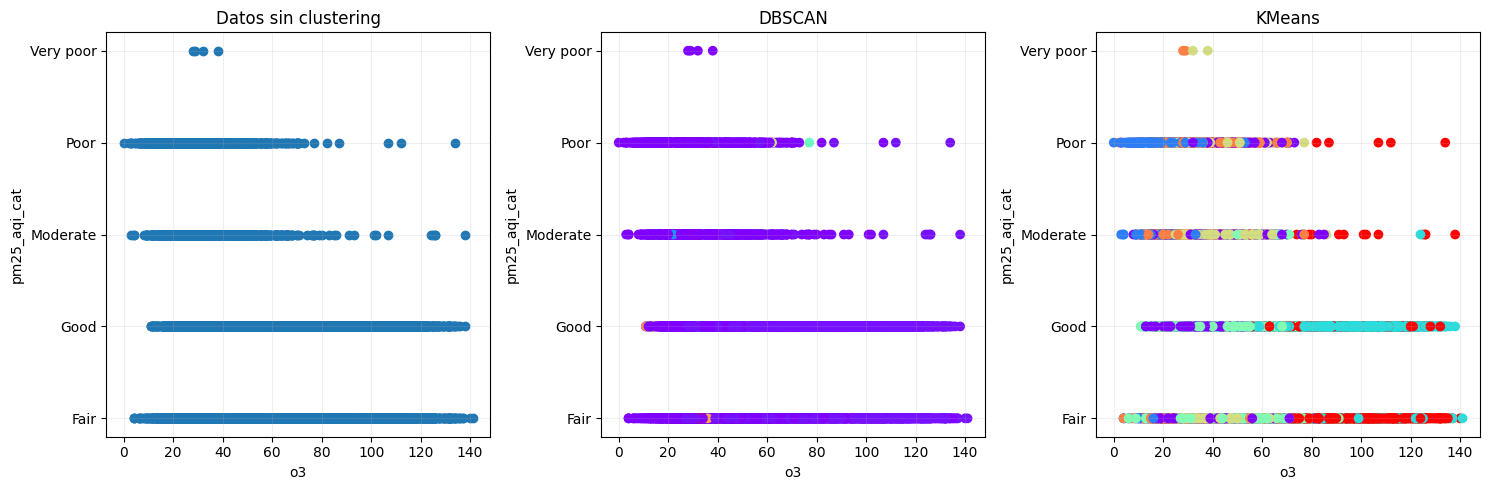

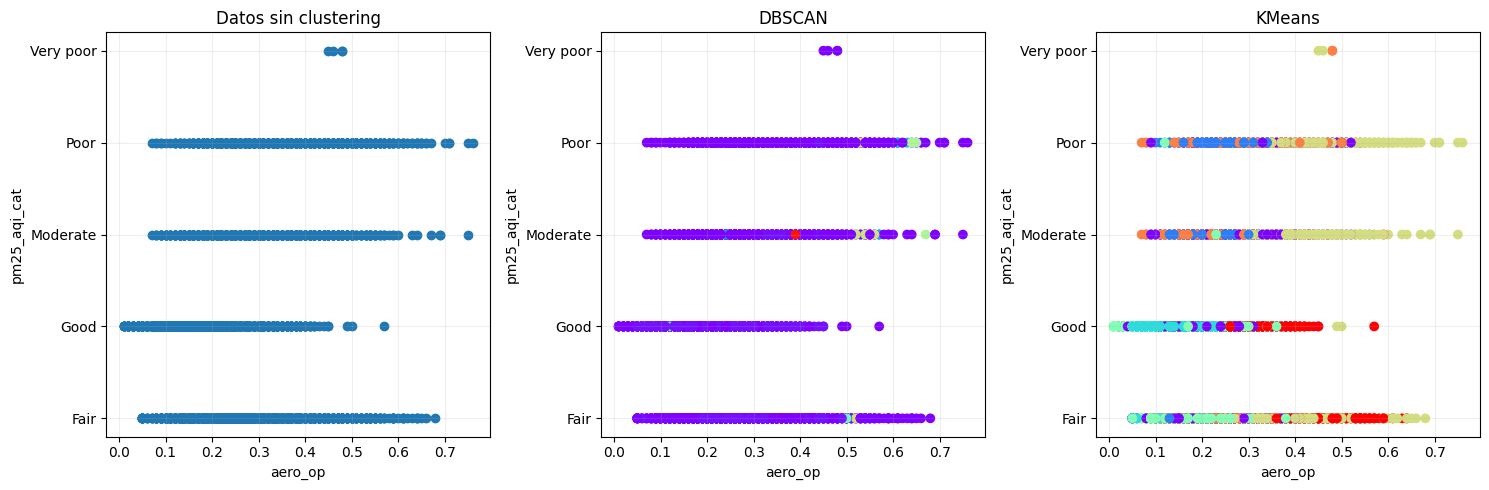

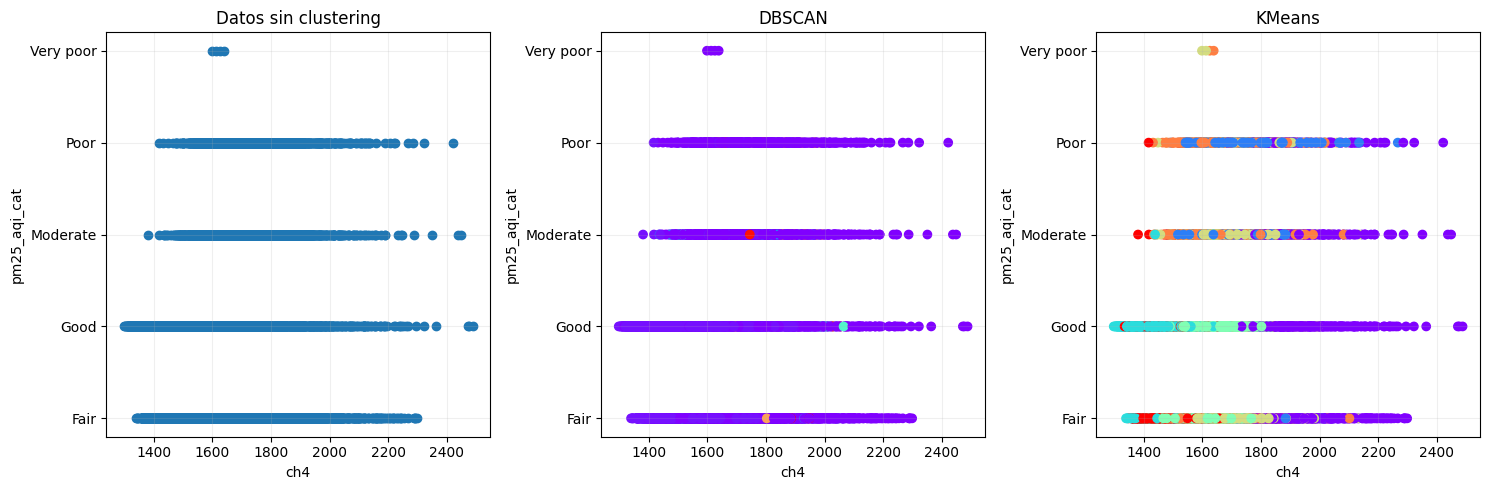

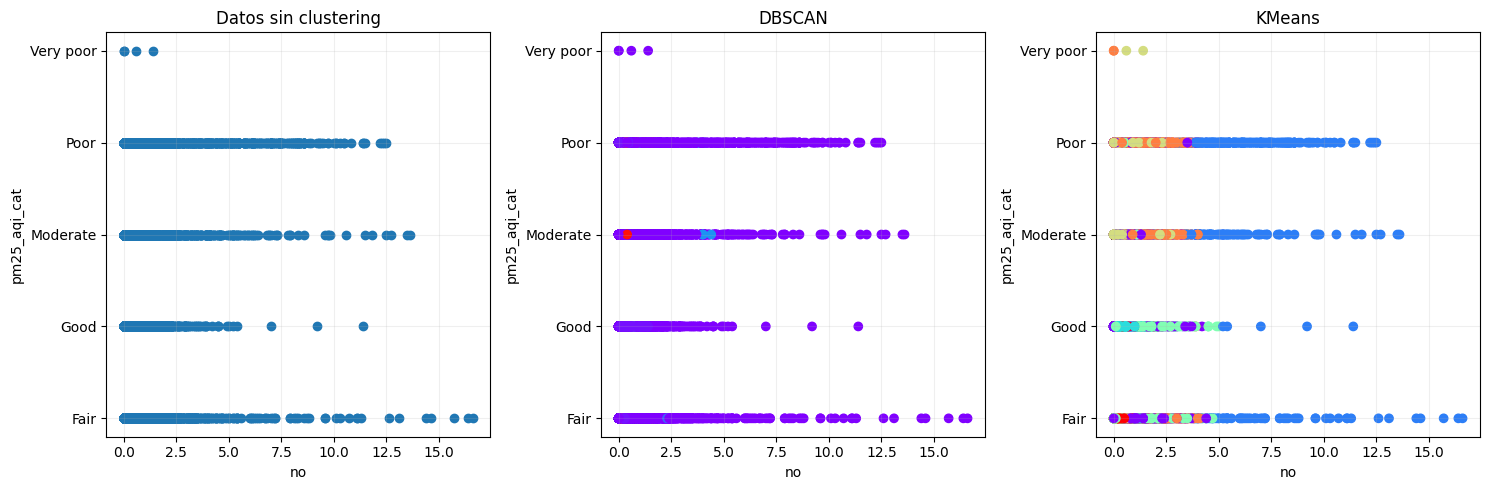

In [46]:
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt

# Ajustar KMeans
kmeans = KMeans(n_clusters=7, n_init="auto", random_state=42)
df_air["cluster_kmeans"] = kmeans.fit_predict(X_scaled_air)

# Ajustar DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
df_air["cluster_dbscan"] = dbscan.fit_predict(X_scaled_air)

# Para cada variable, graficar los 3 escenarios
for var in features_air:

    plt.figure(figsize=(15,5))

    # 1) Datos sin clustering
    plt.subplot(131)
    plt.scatter(df_air[var], df_air["pm25_aqi_cat"])
    plt.xlabel(var)
    plt.ylabel("pm25_aqi_cat")
    plt.title("Datos sin clustering")
    plt.grid(alpha=0.2)

    # 2) DBSCAN
    plt.subplot(132)
    plt.scatter(df_air[var],
                df_air["pm25_aqi_cat"],
                c=df_air["cluster_dbscan"],
                cmap="rainbow")
    plt.xlabel(var)
    plt.ylabel("pm25_aqi_cat")
    plt.title("DBSCAN")
    plt.grid(alpha=0.2)

    # 3) KMeans
    plt.subplot(133)
    plt.scatter(df_air[var],
                df_air["pm25_aqi_cat"],
                c=df_air["cluster_kmeans"],
                cmap="rainbow")
    plt.xlabel(var)
    plt.ylabel("pm25_aqi_cat")
    plt.title("KMeans")
    plt.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


# **Agglomerative Clustering**
🔹 Dendrograma para seleccionar número de clusters

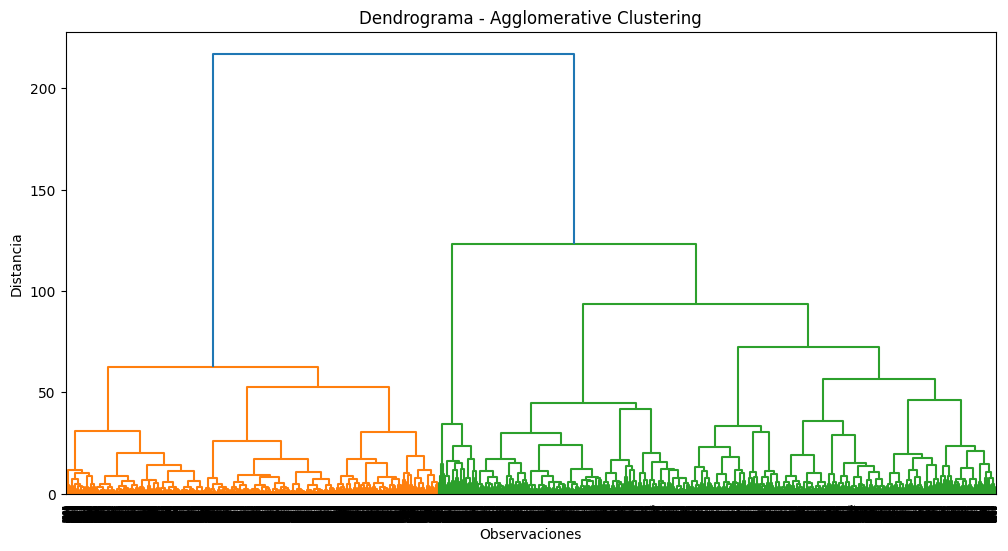

In [47]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

linked = linkage(X_scaled_air, method='ward')
plt.figure(figsize=(12,6))
dendrogram(linked, truncate_mode='level', p=30)
plt.title('Dendrograma - Agglomerative Clustering')
plt.xlabel('Observaciones')
plt.ylabel('Distancia')
plt.show()


**ENTRENAR**

In [48]:
agglo = AgglomerativeClustering(n_clusters=3)  # según dendrograma
df_air["cluster_agg"] = agglo.fit_predict(X_scaled_air)


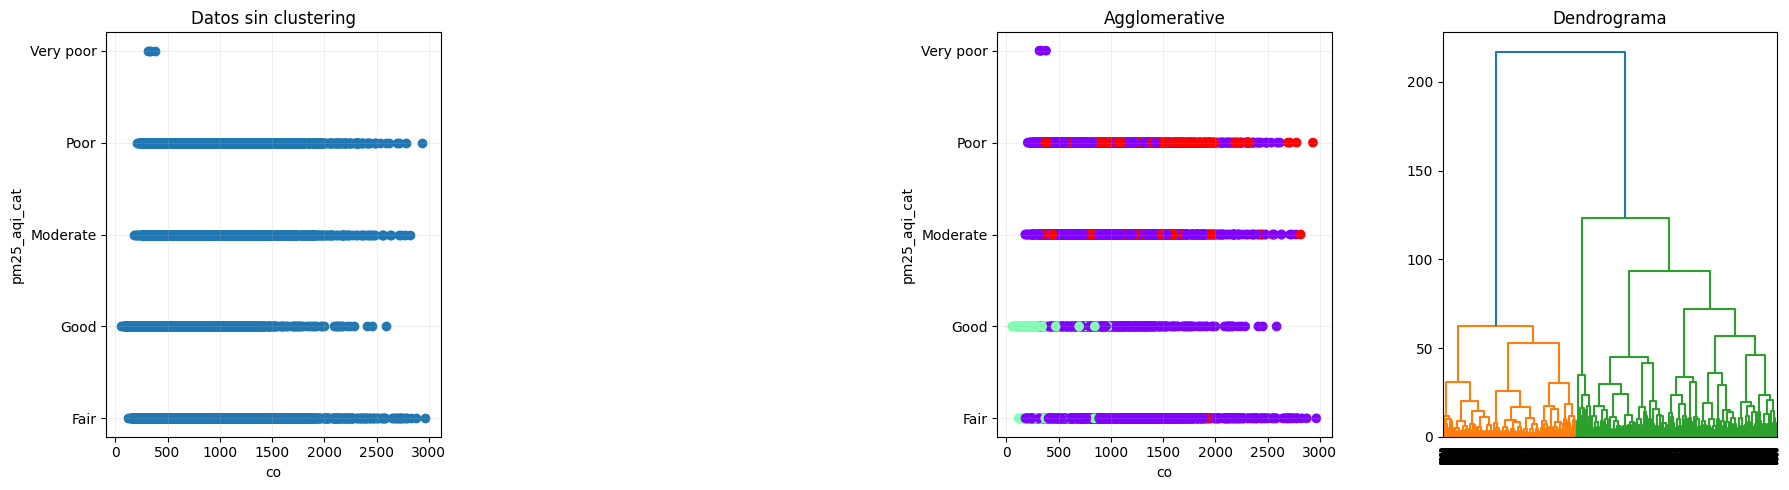

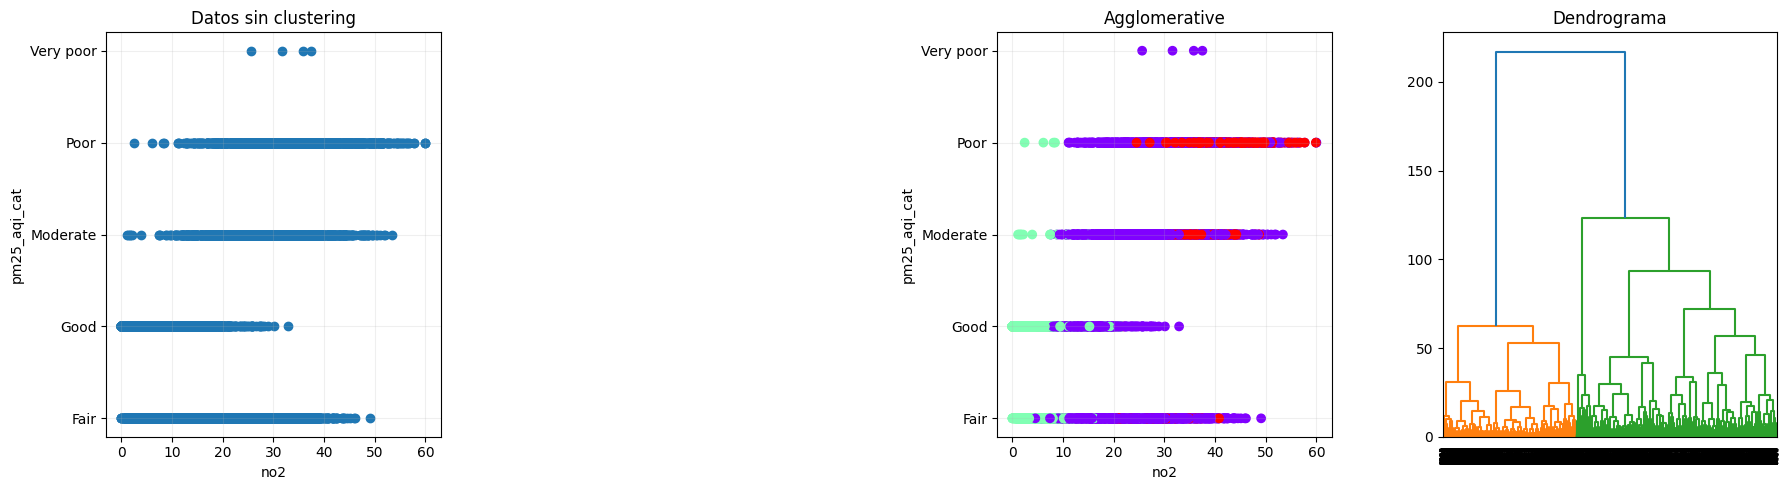

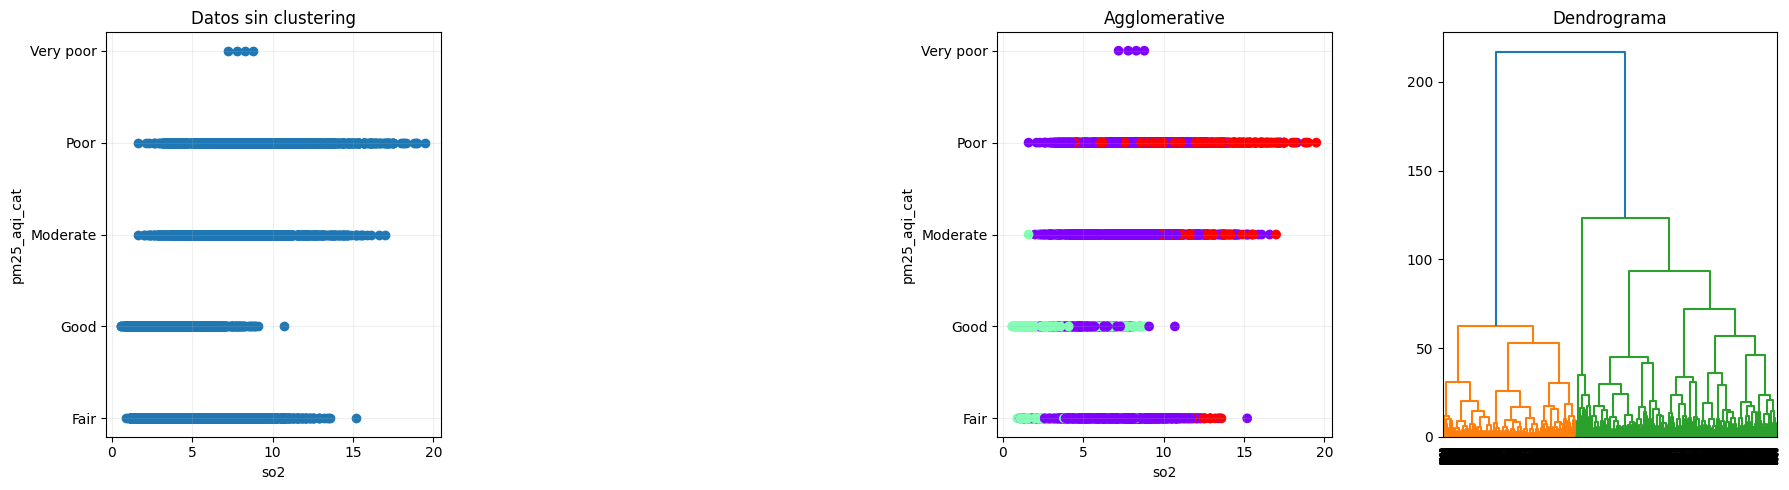

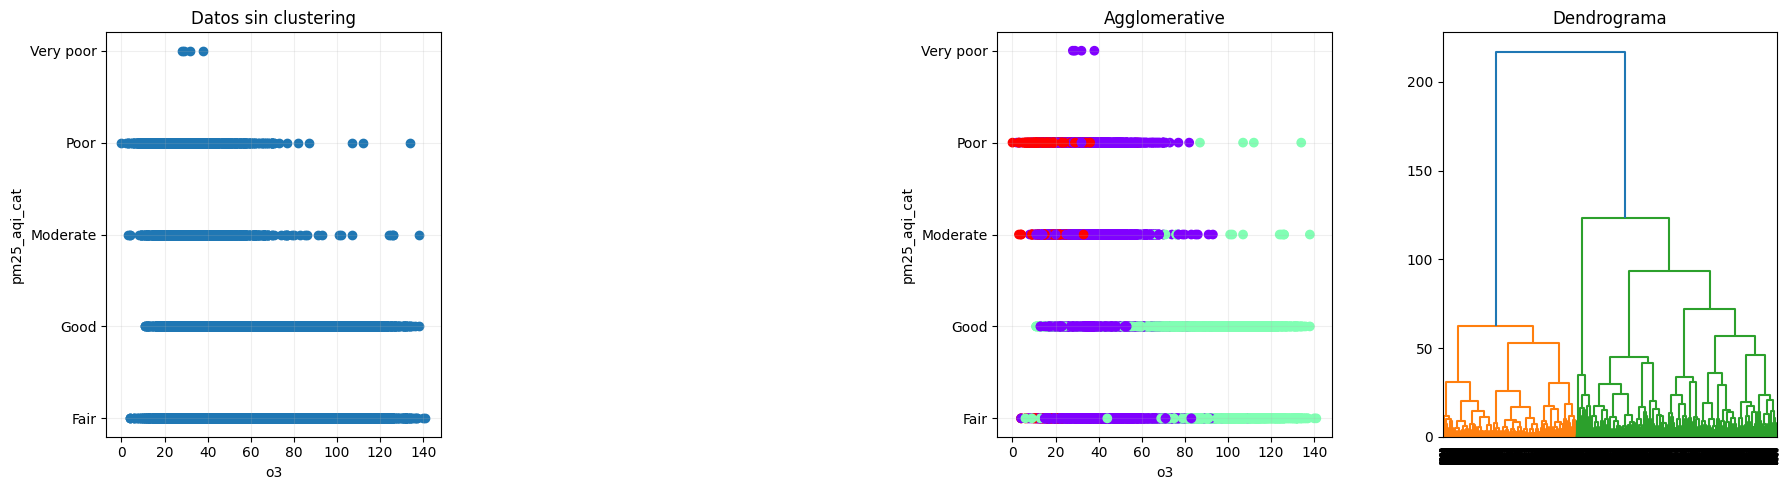

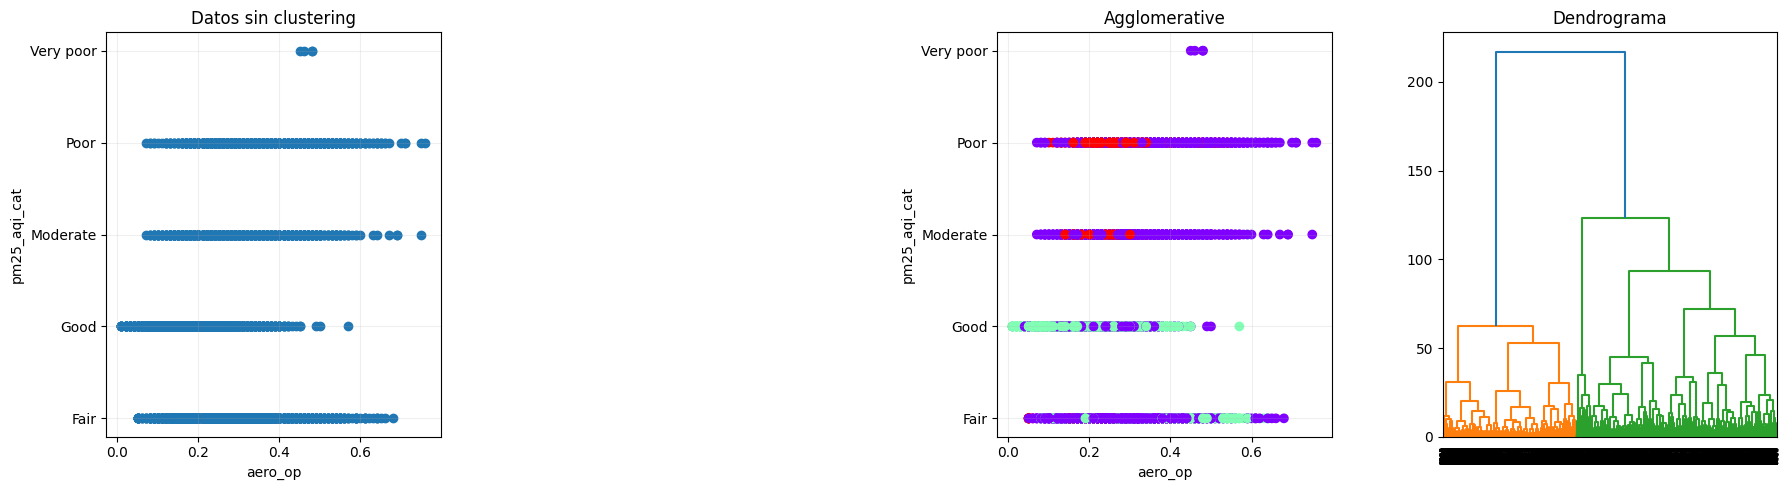

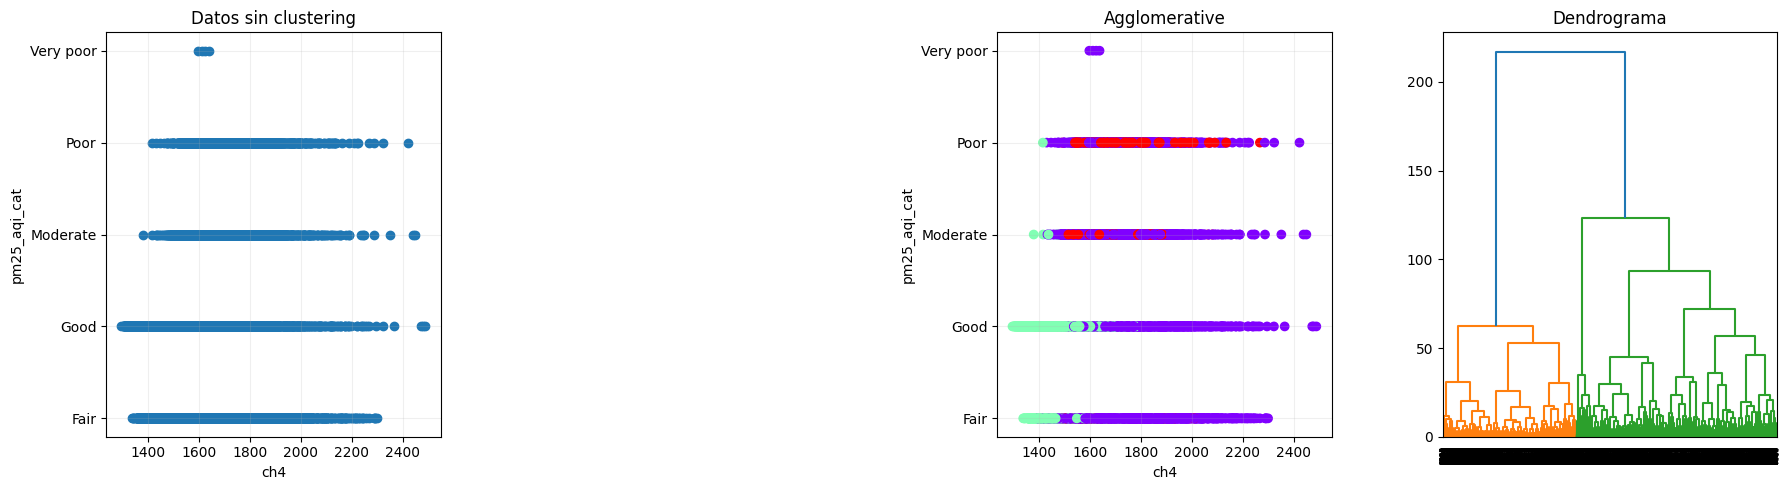

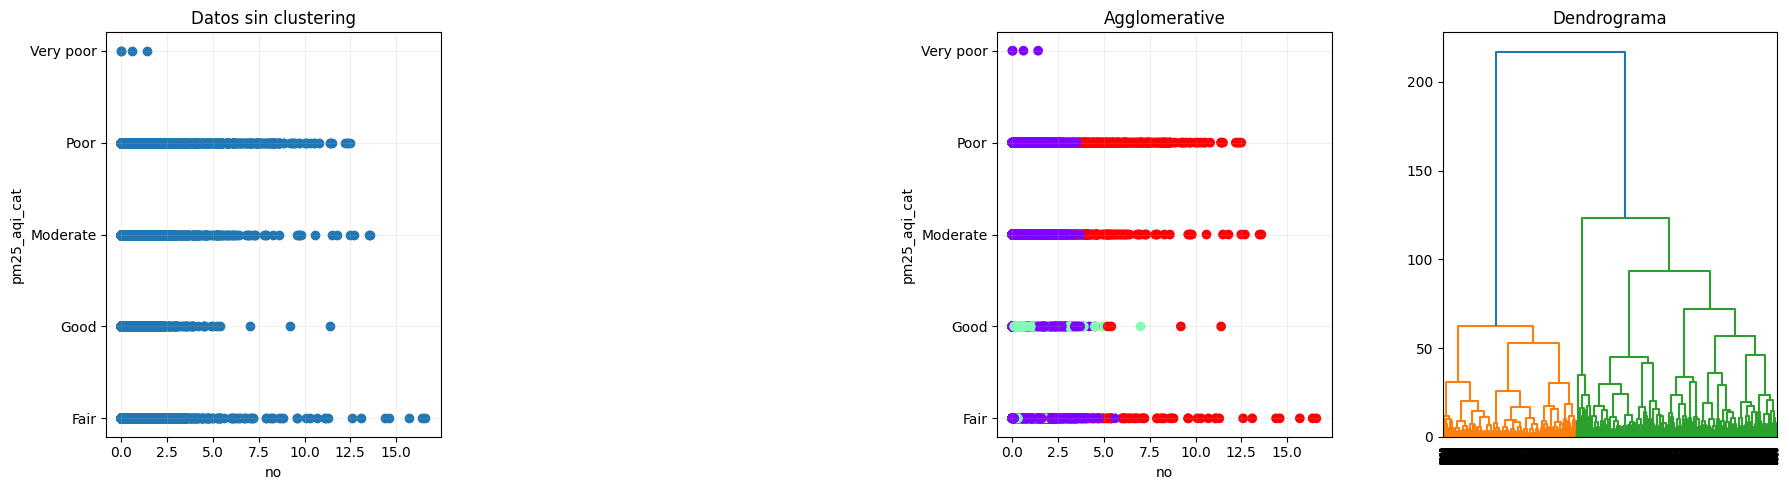

In [49]:
import scipy.cluster.hierarchy as sch

for var in features_air:

    plt.figure(figsize=(18,5))

    # 1) Datos sin clustering
    plt.subplot(141)
    plt.scatter(df_air[var], df_air["pm25_aqi_cat"])
    plt.xlabel(var)
    plt.ylabel("pm25_aqi_cat")
    plt.title("Datos sin clustering")
    plt.grid(alpha=0.2)

    # 2) Agglomerative clustering
    plt.subplot(143)
    plt.scatter(df_air[var],
                df_air["pm25_aqi_cat"],
                c=df_air["cluster_agg"],
                cmap="rainbow")
    plt.xlabel(var)
    plt.ylabel("pm25_aqi_cat")
    plt.title("Agglomerative")
    plt.grid(alpha=0.2)

    # 3) Dendrograma (usa datos escalados)
    Z = sch.linkage(X_scaled_air, method="ward")

    plt.subplot(144)
    sch.dendrogram(Z)
    plt.title("Dendrograma")

    plt.tight_layout()
    plt.show()


**Métricas para evaluar compactación y separación interna: Silhouette Score**

In [53]:
sil_aggl = safe_silhouette(X_scaled_weather, df_air["cluster_agg"])
print("Silhouette AGGLOMERATIVE:", sil_aggl)

Silhouette AGGLOMERATIVE: 0.020423202


 **2. Comparación con etiquetas verdaderas:
○ Clasificación: comparar con etiquetas verdaderas, calculando métricas
como el Accuracy o usando herramientas como la matriz de confusión.**

Accuracy Agglomerative: 0.5763530927835051


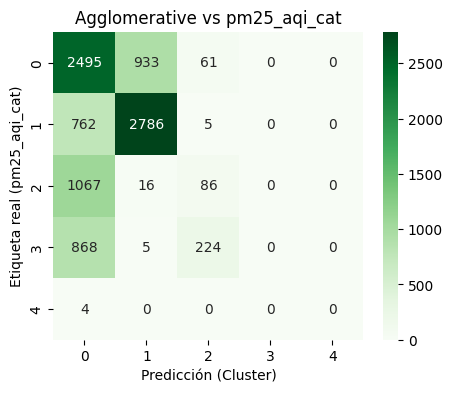

In [55]:
# Predicciones
y_pred_agg = df_air["cluster_agg"]

# Accuracy
acc_agg = accuracy_score(y_true, y_pred_agg)
cm_agg = confusion_matrix(y_true, y_pred_agg)

print("Accuracy Agglomerative:", acc_agg)

# Matriz de confusión
plt.figure(figsize=(5,4))
sns.heatmap(cm_agg, annot=True, fmt="d", cmap="Greens")
plt.title("Agglomerative vs pm25_aqi_cat")
plt.xlabel("Predicción (Cluster)")
plt.ylabel("Etiqueta real (pm25_aqi_cat)")
plt.show()


# Evaluar utilidad de los clusters AIR POLLUTION

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

# Variables predictoras sin clusters
X = df_air[features_air].values
y = df_air["pm25_aqi_cat"].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Baseline
lr_base = LogisticRegression(max_iter=500).fit(X_train, y_train)
rf_base = RandomForestClassifier(random_state=42).fit(X_train, y_train)

acc_lr_base = accuracy_score(y_test, lr_base.predict(X_test))
acc_rf_base = accuracy_score(y_test, rf_base.predict(X_test))

print("Baseline LR:", acc_lr_base)
print("Baseline RF:", acc_rf_base)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Baseline LR: 0.6097691894793345
Baseline RF: 0.7767042404723564


In [57]:
def evaluar_cluster(df, col_cluster):
    Xc = np.column_stack([df[features_air].values,
                          df[col_cluster].values])

    Xc_train, Xc_test, yc_train, yc_test = train_test_split(
        Xc, y, test_size=0.2, random_state=42, stratify=y
    )

    lr = LogisticRegression(max_iter=500).fit(Xc_train, yc_train)
    rf = RandomForestClassifier(random_state=42).fit(Xc_train, yc_train)

    return (
        accuracy_score(yc_test, lr.predict(Xc_test)),
        accuracy_score(yc_test, rf.predict(Xc_test))
    )


In [ ]:
acc_lr_kmeans, acc_rf_kmeans = evaluar_cluster(df_air, "cluster_kmeans")
acc_lr_dbscan, acc_rf_dbscan = evaluar_cluster(df_air, "cluster_dbscan")
acc_lr_agg,    acc_rf_agg    = evaluar_cluster(df_air, "cluster_agg")

print("KMeans -> LR:", acc_lr_kmeans, " RF:", acc_rf_kmeans)
print("DBSCAN -> LR:", acc_lr_dbscan, " RF:", acc_rf_dbscan)
print("Agg    -> LR:", acc_lr_agg,    " RF:", acc_rf_agg)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
tabla = pd.DataFrame({
    "Algoritmo": ["Sin clusters", "KMeans", "DBSCAN", "Agglomerative"],
    "Accuracy LR": [acc_lr_base, acc_lr_kmeans, acc_lr_dbscan, acc_lr_agg],
    "Accuracy RF": [acc_rf_base, acc_rf_kmeans, acc_rf_dbscan, acc_rf_agg]
})

print(tabla)


# **PERSPECTIVAS Y CONCLUSIONES PUNTO 1 (50%)**

***Conclusiones finales del análisis de clustering***

**1. Selección de hiperparámetros**

**KMeans**
Se eligió el número de clusters usando el método del codo, se mostró un codo claro, lo cual sugería un número razonable de clusters. Sin embargo, al aplicar el algoritmo, los clusters resultantes no mostraron una separación significativa. Esto indica que, aunque el codo era visualmente marcado, no correspondía a una estructura real útil en los datos, sino a una disminución mecánica de la inercia.


**DBSCAN**

Los parámetros eps y min_samples se eligieron mediante el k-distance plot, detectando el punto donde la curva cambiaba de pendiente. Esto ayudó a evitar que el algoritmo generara ruido excesivo, aunque aún así terminó fragmentando algunos sectores de los datos.

**Agglomerative**

El número de clusters se seleccionó observando el dendrograma y cortando en la parte más alta donde había una separación evidente entre ramas. Fue el método más intuitivo para decidir la estructura.


**2. Resultados sobre clima**

Los datos climáticos mostraron comportamientos continuos, sin divisiones naturales.
Aunque el codo de KMeans parecía sugerir un buen número de clusters, los resultados mostraron que esos grupos no eran coherentes en las visualizaciones 2D.
Agglomerative generó separaciones ligeramente más limpias, pero siguen siendo débiles.
DBSCAN tuvo mejor Silhouette (~0.44), pero esto ocurrió por capturar solo pequeñas zonas densas y marcar muchos puntos como ruido.

Cuando los IDs de cluster se añadieron como característica adicional a los modelos de regresión (Linear Regression y Random Forest), el rendimiento permaneció igual.
Esto confirma que los clusters no capturaban información relevante para el comportamiento climático.

**3. Resultados sobre contaminación del aire**

Aquí existía una etiqueta real (pm25_aqi_cat), por lo que se pudo evaluar la calidad del clustering de forma más directa.

KMeans: accuracy muy bajo (~8 %), los clusters no se alinean con las categorías reales.

DBSCAN: un poco mejor (~37 %), pero con clusters pequeños y mucho ruido.

Agglomerative: el mejor (~57 %), aunque aún insuficiente para representar correctamente las clases.

Los Silhouette fueron negativos o muy bajos en casi todos los casos, indicando solapamiento entre clases.
Al usar los clusters como variable en clasificadores supervisados, el desempeño no mejoró.
Los modelos supervisados ya capturaban mejor las relaciones entre los contaminantes y la categoría del aire.

Conclusión: Las categorías de pm25 no se reflejan como grupos naturales cuando se analizan sin supervisión.

**4. Comparación general**

KMeans encontró clusters equilibrados pero poco significativos. El codo parecía prometedor, pero la estructura no era real.

DBSCAN detectó patrones locales, pero no generalizables, y trató muchos puntos como ruido.

Agglomerative fue el más coherente visualmente, aunque tampoco logró alinearse con las categorías reales ni aportar valor predictivo.

En ambos dominios, los métodos no supervisados no superaron a los supervisados, y tampoco aportaron nueva información relevante.


***Perspectivas***

--Las variables climáticas cambian suavemente y se solapan, lo que reduce la capacidad de formar clústeres claros.

--Los métodos no supervisados muestran grupos débiles, lo cual indica que las variables meteorológicas del dataset no forman patrones naturales fuertes y tienden a mezclarse entre sí.
Esto coincide con que K-Means, DBSCAN y Agglomerative solo mejoraron marginalmente.

--El codo no fue concluyente, lo que sugiere que la estructura interna del dataset no tiene una segmentación clara, sino transiciones suaves entre estados climáticos.

--Los modelos supervisados sí lograron buen desempeño, especialmente Random Forest; esto significa que la variable categórica PM_CATEGORY_AQI sí tiene relación con las variables, pero esa relación no es agrupable sin etiquetas.

--La contaminación depende de factores no incluidos (emisiones locales, tráfico, topografía), por lo que el clustering con variables puramente meteorológicas no puede capturar completamente las diferencias de calidad del aire.


# Tuning de hiperparámetros

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import numpy as np

Ks = range(2, 13)

sil_scores = []
ch_scores = []
db_scores = []

for k in Ks:
    kmeans = KMeans(n_clusters=k, n_init="auto", random_state=42).fit(X_scaled_air)
    labels = kmeans.labels_

    sil_scores.append(silhouette_score(X_scaled_air, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled_air, labels))
    db_scores.append(davies_bouldin_score(X_scaled_air, labels))

print("Mejor k por Silhouette:", Ks[np.argmax(sil_scores)])
print("Mejor k por Calinski-Harabasz:", Ks[np.argmax(ch_scores)])
print("Mejor k por Davies-Bouldin:", Ks[np.argmin(db_scores)])


# Punto 2 - - Reducción de dimensionalidad (50%)

Varianza explicada 2 componentes PCA: [0.47643214 0.11127025]
Varianza explicada 3 componentes PCA: [0.47643214 0.11127025 0.07020816]
Varianza explicada 5 componentes PCA: [0.47643214 0.11127025 0.07020816 0.06803279 0.05108019 0.04261255
 0.03650371 0.02996621]


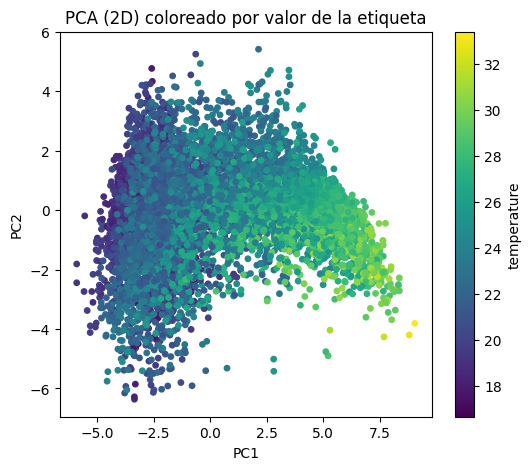

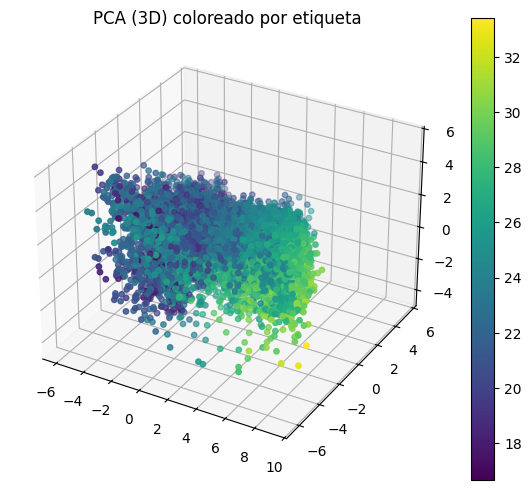

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


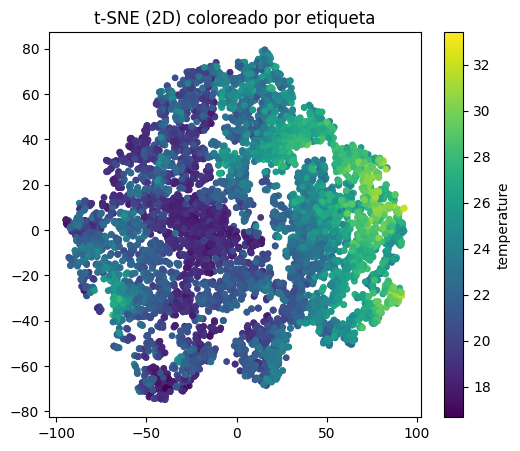


=== MÉTRICAS MODELO CON DATOS ORIGINALES ===
MSE: 0.07331957938108227
R2: 0.9921650525423445

=== MÉTRICAS MODELO CON PCA (2 COMPONENTES) ===
MSE: 3.733830592638188
R2: 0.6010019866991395

=== MÉTRICAS MODELO CON PCA (3 COMPONENTES) ===
MSE: 2.3448103417078823
R2: 0.7494330166576427

=== MÉTRICAS MODELO CON PCA (8 COMPONENTES) ===
MSE: 0.6402042906067916
R2: 0.9315876192769871

=== MÉTRICAS MODELO CON T-SNE (2 COMPONENTES) ===
MSE: 0.6355502650316139
R2: 0.9320849495420528


In [ ]:
#  REDUCCIÓN DE DIMENSIONALIDAD: PCA y T-SNE

from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor


# 1) CARGA DE DATOS Y DEFINICIÓN DE FEATURES


# df = pd.read_csv("tu_archivo.csv")   # si lo necesitas
# Asumimos que ya tienes df cargado desde el ejercicio anterior

# Seleccionar solo columnas numéricas
df = df_full
features = df.select_dtypes(include=[np.number]).columns.tolist()


# DEFINIR VARIABLE OBJETIVO

# EJEMPLO: Regresión prediciendo temperatura
target = "temperature"     # <-- CAMBIAR si usas otra variable

features.remove(target)

X = df[features].fillna(df[features].mean())
y = df[target].fillna(df[target].mean())

# Escalar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



# 2) PCA (2D y 3D)

pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

pca5 = PCA(n_components=8)
X_pca5 = pca5.fit_transform(X_scaled)

print("Varianza explicada 2 componentes PCA:", pca2.explained_variance_ratio_)
print("Varianza explicada 3 componentes PCA:", pca3.explained_variance_ratio_)
print("Varianza explicada 5 componentes PCA:", pca5.explained_variance_ratio_)

# ----- Visualización PCA 2D -----
plt.figure(figsize=(6,5))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=y, cmap='viridis', s=15)
plt.colorbar(label=target)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2D) coloreado por valor de la etiqueta")
plt.show()

# ----- Visualización PCA 3D -----
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=y, cmap='viridis', s=15)
fig.colorbar(p)
ax.set_title("PCA (3D) coloreado por etiqueta")
plt.show()



# 3) T-SNE (2D)

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000)
X_tsne2 = tsne.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_tsne2[:,0], X_tsne2[:,1], c=y, cmap='viridis', s=15)
plt.colorbar(label=target)
plt.title("t-SNE (2D) coloreado por etiqueta")
plt.show()


# 4) MODELO SUPERVISADO CON DATOS REDUCIDOS


# División entrenamiento / prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Modelo original
model = RandomForestRegressor(random_state=0)

# Entrenar con datos originales
model.fit(X_train, y_train)
pred_orig = model.predict(X_test)

# Métricas
mse_orig = mean_squared_error(y_test, pred_orig)
r2_orig = r2_score(y_test, pred_orig)

print("\n=== MÉTRICAS MODELO CON DATOS ORIGINALES ===")
print("MSE:", mse_orig)
print("R2:", r2_orig)


# --------- PCA 2D como entrada al modelo ----------
Xp_train, Xp_test, _, _ = train_test_split(X_pca2, y, test_size=0.2, random_state=0)

model_pca = RandomForestRegressor(random_state=0)
model_pca.fit(Xp_train, y_train)
pred_pca = model_pca.predict(Xp_test)

mse_pca = mean_squared_error(y_test, pred_pca)
r2_pca = r2_score(y_test, pred_pca)

print("\n=== MÉTRICAS MODELO CON PCA (2 COMPONENTES) ===")
print("MSE:", mse_pca)
print("R2:", r2_pca)

# --------- PCA 3D como entrada al modelo ----------
Xp_train, Xp_test, _, _ = train_test_split(X_pca3, y, test_size=0.2, random_state=0)

model_pca = RandomForestRegressor(random_state=0)
model_pca.fit(Xp_train, y_train)
pred_pca = model_pca.predict(Xp_test)

mse_pca = mean_squared_error(y_test, pred_pca)
r2_pca = r2_score(y_test, pred_pca)

print("\n=== MÉTRICAS MODELO CON PCA (3 COMPONENTES) ===")
print("MSE:", mse_pca)
print("R2:", r2_pca)

# --------- PCA 5D como entrada al modelo ----------
Xp_train, Xp_test, _, _ = train_test_split(X_pca5, y, test_size=0.2, random_state=0)

model_pca = RandomForestRegressor(random_state=0)
model_pca.fit(Xp_train, y_train)
pred_pca = model_pca.predict(Xp_test)

mse_pca = mean_squared_error(y_test, pred_pca)
r2_pca = r2_score(y_test, pred_pca)

print("\n=== MÉTRICAS MODELO CON PCA (8 COMPONENTES) ===")
print("MSE:", mse_pca)
print("R2:", r2_pca)

# --------- t-SNE 2D como entrada al modelo ----------
Xt_train, Xt_test, _, _ = train_test_split(X_tsne2, y, test_size=0.2, random_state=0)

model_tsne = RandomForestRegressor(random_state=0)
model_tsne.fit(Xt_train, y_train)
pred_tsne = model_tsne.predict(Xt_test)

mse_tsne = mean_squared_error(y_test, pred_tsne)
r2_tsne = r2_score(y_test, pred_tsne)

print("\n=== MÉTRICAS MODELO CON T-SNE (2 COMPONENTES) ===")
print("MSE:", mse_tsne)
print("R2:", r2_tsne)


En este ejercicio se aplicaron técnicas de reducción de dimensionalidad (PCA y t-SNE) para evaluar cómo cambia el rendimiento de un modelo supervisado al usar versiones reducidas de los datos. Posteriormente, se entrenó el mismo modelo de regresión con:

1.   los datos originales
2.   Datos transformados con PCA (2, 3 y 8 componentes)
3. datos transformados con t-SNE (2 componentes)

El modelo con los datos originales obtuvo el mejor desempeño `(MSE muy bajo y R² ≈ 0.99)`, lo cual indica que la información completa del dataset es altamente predictiva. Al reducir a solo 2 y 3 componentes con PCA, el rendimiento cae notablemente porque estas pocas componentes no capturan suficiente variabilidad y se pierde información relevante para la regresión. Al aumentar PCA a 8 componentes, las métricas mejoran significativamente `(R² ≈ 0.93)`, porque se retiene mucha más varianza del conjunto original. Por su parte, t-SNE con 2 componentes produce un rendimiento similar a PCA con 8 componentes, ya que t-SNE preserva bien las relaciones locales del espacio original, aunque también elimina información global necesaria para predecir con precisión. En conjunto, los resultados muestran que la reducción de dimensionalidad facilita visualización, pero no mejora el rendimiento del modelo, y solo cuando se conserva una mayor proporción de la estructura original (como en PCA con 8 componentes) se obtienen resultados cercanos a los datos completos.

**¿Qué es la varianza en el contexto de PCA y reducción de dimensionalidad?**

La varianza mide qué tanto cambian o se dispersan los datos en una dirección determinada. En PCA, cada componente principal captura una parte de esa variación total del conjunto original.

**Alta varianza =** mucha información relevante sobre cómo cambian los datos.

**Baja varianza =** poca información, usualmente ruido o detalles menos importantes.

Cuando se reduce la dimensionalidad, lo ideal es conservar la mayor cantidad posible de varianza, porque eso significa que se esta reteniendo la estructura y relaciones importantes del dataset. Por eso, cuando se uso PCA con solo 2 o 3 componentes, el modelo perdió rendimiento: esas pocas componentes no alcanzan a almacenar toda la variabilidad del conjunto original. En cambio, con 8 componentes, se conservó mucha más varianza, lo que permitió que el modelo tuviera un desempeño mucho más cercano al original.

=== MÉTRICAS MODELO CON DATOS ORIGINALES ===
MSE: 9.290319
R2: 0.870631

=== MÉTRICAS MODELO CON PCA (2 COMPONENTES) ===
MSE: 34.742201
R2: 0.516210
Varianza explicada por componentes (primeros 5 si existen): [0.48601028 0.1079426 ]

=== MÉTRICAS MODELO CON PCA (3 COMPONENTES) ===
MSE: 26.849681
R2: 0.626115
Varianza explicada por componentes (primeros 5 si existen): [0.48601028 0.1079426  0.07442488]

=== MÉTRICAS MODELO CON PCA (8 COMPONENTES) ===
MSE: 15.900433
R2: 0.778584
Varianza explicada por componentes (primeros 5 si existen): [0.48601028 0.1079426  0.07442488 0.06977031 0.04496447]



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


=== MÉTRICAS MODELO CON T-SNE (2 COMPONENTES) ===
MSE: 14.310697
R2: 0.800722



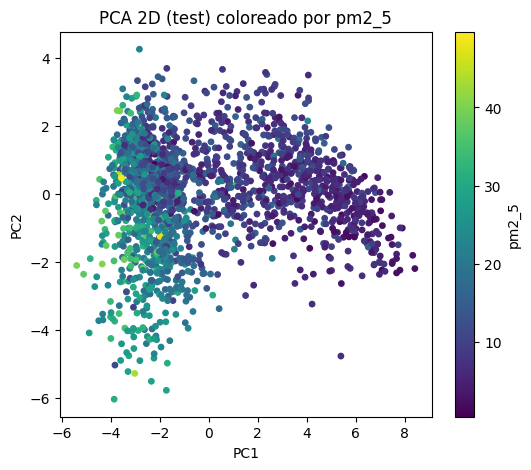

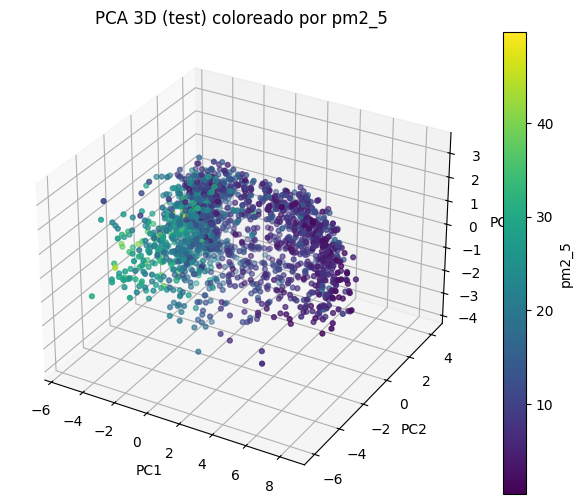

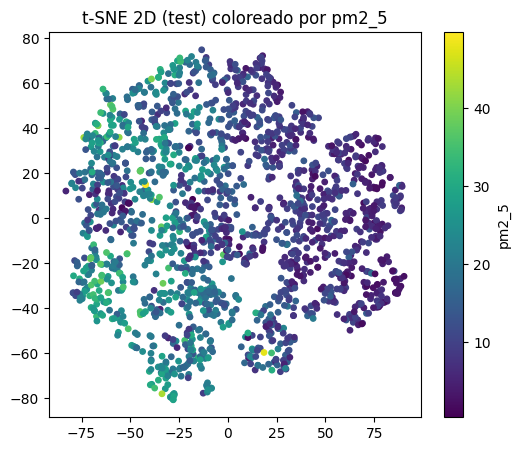

=== RESUMEN COMPARATIVO ===
     method        mse        r2
0  Original   9.290319  0.870631
1   t-SNE_2  14.310697  0.800722
2     PCA_8  15.900433  0.778584
3     PCA_3  26.849681  0.626115
4     PCA_2  34.742201  0.516210


In [ ]:
# Predicción de pm2_5

# ---------- 0) Config ----------
RANDOM_STATE = 0
TEST_SIZE = 0.2

# ---------- 1) Preparar datos ----------
# df_full ya existe en tu notebook según indicas.
df = df_full.copy()

# Eliminar columnas no numéricas que no deseamos usar (ej: 'date', strings)
cols_to_drop = ['date'] if 'date' in df.columns else []
df = df.drop(columns=cols_to_drop)

# Target y features
target = 'pm2_5'
if target not in df.columns:
    raise ValueError(f"No encuentro la columna objetivo '{target}' en df_full")

# Seleccionar sólo columnas numéricas (excluyendo target)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
features = [c for c in numeric_cols if c != target]

X = df[features].copy()
y = df[target].copy()

# Imputar NA con media (simple y reproducible)
X = X.fillna(X.mean())
y = y.fillna(y.mean())

# ---------- 2) Train/test split (hacerlo una vez para comparabilidad) ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# ---------- 3) Escalado (fit sólo con train) ----------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------- 4) Definir y entrenar modelo con datos originales ----------
rf_params = {'n_estimators': 200, 'random_state': RANDOM_STATE}
model_orig = RandomForestRegressor(**rf_params)
model_orig.fit(X_train_scaled, y_train)
pred_orig = model_orig.predict(X_test_scaled)
mse_orig = mean_squared_error(y_test, pred_orig)
r2_orig = r2_score(y_test, pred_orig)

print("=== MÉTRICAS MODELO CON DATOS ORIGINALES ===")
print(f"MSE: {mse_orig:.6f}")
print(f"R2: {r2_orig:.6f}\n")

# ---------- 5) PCA con 2, 3 y 8 componentes ----------
pca_components = [2, 3, 8]
pca_results = {}

for n_comp in pca_components:
    pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
    Xp_train = pca.fit_transform(X_train_scaled)
    Xp_test = pca.transform(X_test_scaled)

    # Entrenar modelo sobre componentes PCA
    model_pca = RandomForestRegressor(**rf_params)
    model_pca.fit(Xp_train, y_train)
    pred_pca = model_pca.predict(Xp_test)

    mse_pca = mean_squared_error(y_test, pred_pca)
    r2_pca = r2_score(y_test, pred_pca)

    pca_results[n_comp] = {
        'mse': mse_pca,
        'r2': r2_pca,
        'explained_variance_ratio': pca.explained_variance_ratio_
    }

    print(f"=== MÉTRICAS MODELO CON PCA ({n_comp} COMPONENTES) ===")
    print(f"MSE: {mse_pca:.6f}")
    print(f"R2: {r2_pca:.6f}")
    print(f"Varianza explicada por componentes (primeros 5 si existen): {pca.explained_variance_ratio_[:5]}")
    print()

# ---------- 6) t-SNE (2 componentes) ----------
# Nota: t-SNE es principalmente para visualización; aun así lo usamos para entrenar y comparar.
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1000, random_state=RANDOM_STATE)
# Ajustar t-SNE con X_train_scaled y transformar train+test (transform no está disponible para TSNE,
# así que concatenamos y luego separamos para consistencia; alternativa: ajustar separado en train y test,
# pero para mantener pares, usamos concatenación y reproducibilidad).
X_all_scaled = np.vstack([X_train_scaled, X_test_scaled])
X_all_tsne = tsne.fit_transform(X_all_scaled)
Xp_train_tsne = X_all_tsne[:len(X_train_scaled)]
Xp_test_tsne = X_all_tsne[len(X_train_scaled):]

model_tsne = RandomForestRegressor(**rf_params)
model_tsne.fit(Xp_train_tsne, y_train)
pred_tsne = model_tsne.predict(Xp_test_tsne)
mse_tsne = mean_squared_error(y_test, pred_tsne)
r2_tsne = r2_score(y_test, pred_tsne)

print("=== MÉTRICAS MODELO CON T-SNE (2 COMPONENTES) ===")
print(f"MSE: {mse_tsne:.6f}")
print(f"R2: {r2_tsne:.6f}\n")

# ---------- 7) Visualizaciones ----------
# PCA 2D scatter (usar PCA ajustado con n=2)
pca2_for_plot = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2_all = pca2_for_plot.fit_transform(X_all_scaled)
X_pca2_train = X_pca2_all[:len(X_train_scaled)]
X_pca2_test = X_pca2_all[len(X_train_scaled):]

plt.figure(figsize=(6,5))
sc = plt.scatter(X_pca2_test[:,0], X_pca2_test[:,1], c=y_test, s=15)
plt.colorbar(sc, label='pm2_5')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D (test) coloreado por pm2_5')
plt.show()

# PCA 3D plot (usar PCA con n=3)
pca3_for_plot = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3_all = pca3_for_plot.fit_transform(X_all_scaled)
X_pca3_test = X_pca3_all[len(X_train_scaled):]

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(X_pca3_test[:,0], X_pca3_test[:,1], X_pca3_test[:,2], c=y_test, s=12)
fig.colorbar(p, label='pm2_5')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
plt.title('PCA 3D (test) coloreado por pm2_5')
plt.show()

# t-SNE 2D (usamos Xp_test_tsne)
plt.figure(figsize=(6,5))
sc = plt.scatter(Xp_test_tsne[:,0], Xp_test_tsne[:,1], c=y_test, s=15)
plt.colorbar(sc, label='pm2_5')
plt.title('t-SNE 2D (test) coloreado por pm2_5')
plt.show()

# ---------- 8) Resumen final en DataFrame ----------
summary = []
summary.append({'method': 'Original', 'mse': mse_orig, 'r2': r2_orig})
for k,v in pca_results.items():
    summary.append({'method': f'PCA_{k}', 'mse': v['mse'], 'r2': v['r2']})
summary.append({'method': 't-SNE_2', 'mse': mse_tsne, 'r2': r2_tsne})

summary_df = pd.DataFrame(summary).sort_values('r2', ascending=False).reset_index(drop=True)
print("=== RESUMEN COMPARATIVO ===")
print(summary_df)

# Opcional: guardar summary_df a csv
# summary_df.to_csv("pm2_5_model_comparison_summary.csv", index=False)


**1. Modelo con datos originales (sin reducción)**

El mejor desempeño corresponde al modelo entrenado con todas las variables originales.
Esto es lógico porque:

- Mantiene el 100% de la información relevante.

- Random Forest funciona especialmente bien cuando tiene muchas características, incluso si algunas son redundantes.

- La predicción de PM2.5 depende de múltiples variables atmosféricas y químicas, y perderlas afecta directamente la capacidad predictiva del modelo.

Conclusión: Este es el modelo más fuerte (MSE más bajo, R² más alto).

**2. PCA (2, 3 y 8 componentes)**

PCA reduce la dimensionalidad seleccionando ejes que maximicen la varianza total de los datos, pero no necesariamente la información relevante para predecir PM2.5.

Esto explica el comportamiento observado:

- PCA 2 y PCA 3 → peor rendimiento:
Con solo 2–3 componentes se pierde demasiada variabilidad asociada al PM2.5.

- PCA 8 → rendimiento intermedio:
Con 8 componentes el modelo conserva más varianza estructural del dataset original
➝ por eso el R² sube a 0.78, mucho mejor que PCA 2 y 3.

En general:

Menos componentes → menor capacidad predictiva del Random Forest.
Más componentes → mejor recuperación de la estructura original.

**3. t-SNE (2D)**

El t-SNE produce resultados mejores que los PCA más agresivos (PCA 2 y PCA 3), pero aún así no supera al modelo original.

t-SNE permite visualizar estructuras locales y agrupamientos, pero:

- No preserva distancias globales.

- No es un método lineal.

- No está diseñado para ser usado como entrada para modelos supervisados.

Esto explica que obtenga un R² de 0.80, mejor que PCA 2–3, pero no mejor que PCA 8 ni que el modelo original.

Conclusión: útil para visualización, pero no para predicción.